# Gaussian Mixture Model (GMM) Unsupervised Learning Analysis

## Objective
Discover natural groupings in student behavior patterns using GMM clustering to identify distinct student profiles.

**Note:** This notebook uses pre-processed and encoded data from `data/final/encoded_unsupervised.csv`.

## Table of Contents
1. [Setup and Imports](#setup)
2. [Load Encoded Data](#data-loading)
3. [Data Overview](#data-overview)
4. [GMM Model Training](#gmm-training)
5. [Model Selection](#model-selection)
6. [Cluster Analysis](#cluster-analysis)
7. [Visualization](#visualization)
8. [Results Export](#export)
9. [Conclusions](#conclusions)

## 1. Setup and Imports <a id='setup'></a>

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
from datetime import datetime
import pickle

# Scikit-learn imports
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score

# Plotting
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Logging setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported successfully!")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All libraries imported successfully!
Timestamp: 2026-01-30 11:37:47


## 2. Load Encoded Data <a id='data-loading'></a>

Load the pre-processed and encoded dataset from `data/final/encoded_unsupervised.csv`.
All preprocessing, encoding, and feature engineering has already been completed.

In [2]:
# Load the pre-processed and encoded dataset
logger.info("Loading encoded dataset...")
data_path = '../data/final/encoded_unsupervised.csv'
df = pd.read_csv(data_path)

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumn names:\n{list(df.columns)}")
print("\nFirst 3 rows:")
df.head(3)

2026-01-30 11:37:47,349 - INFO - Loading encoded dataset...


DATASET LOADED
Shape: 32,548 rows × 25 columns

Memory usage: 6.21 MB

Column names:
['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'date_registration', 'avg_clicks_per_day', 'module_presentation_length', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count', 'avg_submission_delay', 'sites_revisit_ratio', 'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG', 'code_presentation_2013J', 'code_presentation_2014B', 'code_presentation_2014J', 'gender_M', 'disability_Y']

First 3 rows:


,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,date_registration,avg_clicks_per_day,module_presentation_length,tma_cma_weighted_score,total_submissions,...,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_M,disability_Y
0,0.75,1.000000,1.0,-0.368196,3.0,-1.818699,0.765076,0.909289,0.824,0.000,...,0,0,0,0,0,1,0,0,1,0
1,0.75,0.222222,0.5,-0.368196,0.0,0.333158,0.132223,0.909289,0.654,0.000,...,0,0,0,0,0,1,0,0,0,0
2,0.50,0.333333,0.5,-0.368196,0.0,-0.458563,0.309507,0.909289,0.000,-0.625,...,0,0,0,0,0,1,0,0,0,1


## 3. Data Overview <a id='data-overview'></a>

Quick overview of the encoded dataset before training GMM models.

In [3]:
# Data info
print("=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)

# Statistical summary
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
df.describe()

DATA TYPES
highest_education             float64
imd_band                      float64
age_band                      float64
num_of_prev_attempts          float64
studied_credits               float64
date_registration             float64
avg_clicks_per_day            float64
module_presentation_length    float64
tma_cma_weighted_score        float64
total_submissions             float64
late_submissions_count        float64
avg_submission_delay          float64
sites_revisit_ratio           float64
activity_diversity_ratio      float64
code_module_BBB                 int64
code_module_CCC                 int64
code_module_DDD                 int64
code_module_EEE                 int64
code_module_FFF                 int64
code_module_GGG                 int64
code_presentation_2013J         int64
code_presentation_2014B         int64
code_presentation_2014J         int64
gender_M                        int64
disability_Y                    int64
dtype: object

STATISTICAL SUMMARY


,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,date_registration,avg_clicks_per_day,module_presentation_length,tma_cma_weighted_score,total_submissions,...,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_M,disability_Y
count,32548.000000,32548.000000,32548.000000,3.254800e+04,32548.000000,3.254800e+04,3.254800e+04,3.254800e+04,32548.000000,32548.000000,...,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000,32548.000000
mean,0.434873,0.456256,0.151330,1.606733e-16,0.328574,6.287216e-17,2.158292e-02,-2.584744e-16,0.385693,0.042879,...,0.135984,0.192239,0.090082,0.238141,0.077854,0.271445,0.239216,0.345674,0.548390,0.097149
std,0.187410,0.315933,0.236756,1.000015e+00,0.684103,1.000015e+00,8.529501e-01,1.000015e+00,0.346130,0.540580,...,0.342777,0.394066,0.286304,0.425952,0.267946,0.444712,0.426611,0.475595,0.497661,0.296165
min,0.000000,0.000000,0.000000,-3.681955e-01,-0.500000,-5.127688e+00,-1.484743e+00,-1.670921e+00,0.000000,-0.625000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.222222,0.000000,-3.681955e-01,0.000000,-6.209672e-01,-4.651464e-01,-1.139701e+00,0.000000,-0.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.444444,0.000000,-3.681955e-01,0.000000,2.519561e-01,-8.932471e-17,4.539579e-01,0.368150,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.500000,0.777778,0.500000,-3.681955e-01,1.000000,8.203714e-01,5.348536e-01,9.092890e-01,0.727500,0.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,6.670299e+00,9.916667,4.799278e+00,1.187525e+01,9.851775e-01,1.000000,1.125000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# Prepare feature matrix for GMM
logger.info("Preparing feature matrix for GMM training...")

# Use all columns as features (they're already encoded)
X = df.values
feature_names = df.columns.tolist()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Number of samples: {X.shape[0]:,}")

print("\n✓ Data ready for GMM training!")

2026-01-30 11:37:47,593 - INFO - Preparing feature matrix for GMM training...



Feature matrix shape: (32548, 25)
Number of features: 25
Number of samples: 32,548

✓ Data ready for GMM training!


## 4. GMM Model Training <a id='gmm-training'></a>

Train Gaussian Mixture Models with different numbers of clusters and covariance types.

In [7]:
# Dimensionality reduction for visualization and faster training
logger.info("Applying PCA for dimensionality reduction...")

# Apply PCA
pca = PCA(n_components=min(50, X.shape[1]), random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nPCA Results:")
print(f"  - Total components: {pca.n_components_}")
print(f"  - Components for 95% variance: {n_components_95}")
print(f"  - Explained variance (first 10 components): {pca.explained_variance_ratio_[:10]}")
print(f"  - Cumulative variance (first 10): {cumulative_variance[:10]}")

# Use components that explain 95% of variance for GMM training
X_reduced = X_pca[:, :n_components_95]
print(f"\nReduced feature matrix shape: {X_reduced.shape}")
print("\nThis reduction speeds up training while preserving 95% of variance.")

2026-01-30 11:37:48,796 - INFO - Applying PCA for dimensionality reduction...



PCA Results:
  - Total components: 25
  - Components for 95% variance: 9
  - Explained variance (first 10 components): [0.74955778 0.05470994 0.03860378 0.02928312 0.02813316 0.02043684
 0.0130496  0.01217093 0.00975125 0.00876758]
  - Cumulative variance (first 10): [0.74955778 0.80426772 0.84287149 0.87215461 0.90028777 0.92072461
 0.93377421 0.94594514 0.95569639 0.96446397]

Reduced feature matrix shape: (32548, 9)

This reduction speeds up training while preserving 95% of variance.


### 4.0 Understanding Your Features

Before applying PCA, let's understand what each feature represents and why it matters.

In [ ]:
# Create comprehensive feature dictionary
print("=" * 100)
print("FEATURE DICTIONARY - What Each Feature Represents")
print("=" * 100)

feature_explanations = {
    "STUDENT DEMOGRAPHICS": {
        "highest_education": "Student's education level before enrollment (encoded 0-1)",
        "imd_band": "Index of Multiple Deprivation - socioeconomic status (0-1)",
        "age_band": "Age group of the student (encoded 0-1)",
        "gender_M": "Binary: 1=Male, 0=Female",
        "disability_Y": "Binary: 1=Has disability, 0=No disability"
    },
    
    "COURSE INFORMATION": {
        "code_module_BBB/CCC/DDD/EEE/FFF/GGG": "One-hot encoded course modules",
        "code_presentation_2013J/2014B/2014J": "One-hot encoded course presentation/semester",
        "module_presentation_length": "Duration of course in days (normalized)",
        "studied_credits": "Number of credits student is studying (normalized)",
        "num_of_prev_attempts": "Number of previous attempts at this module"
    },
    
    "REGISTRATION & TIMING": {
        "date_registration": "Days before/after course start when student registered (normalized)",
    },
    
    "ENGAGEMENT METRICS": {
        "avg_clicks_per_day": "Average daily platform interactions",
        "total_clicks": "Total interactions with learning platform",
        "active_days": "Number of days student was active on platform",
        "clicks_early": "Clicks in early phase of course",
        "clicks_mid": "Clicks in middle phase of course", 
        "clicks_late": "Clicks in late phase of course"
    },
    
    "CONTENT INTERACTION": {
        "clicks_homepage": "Clicks on course homepage",
        "clicks_oucontent": "Clicks on Open University content pages",
        "clicks_resource": "Clicks on resource materials",
        "clicks_subpage": "Clicks on sub-pages",
        "clicks_url": "Clicks on external URLs",
        "clicks_forumng": "Forum/discussion participation",
        "clicks_quiz": "Quiz interactions",
        "clicks_questionnaire": "Questionnaire interactions"
    },
    
    "ASSESSMENT PERFORMANCE": {
        "tma_cma_weighted_score": "Weighted assessment scores (TMAs + CMAs)",
        "mean_score": "Average score across all assessments",
        "max_score": "Highest score achieved",
        "score_count": "Number of scored assessments",
        "total_submissions": "Total number of submissions",
        "late_submissions_count": "Number of late submissions",
        "avg_submission_delay": "Average days early (negative) or late (positive)",
        "submissions_count": "Count of assessment submissions",
        "assessments_count": "Number of assessments attempted",
        "total_assessments_available": "Total assessments available in course"
    },
    
    "BEHAVIORAL PATTERNS": {
        "sites_revisit_ratio": "How often student revisits same content",
        "activity_diversity_ratio": "Variety of learning activities engaged in"
    }
}

for category, features in feature_explanations.items():
    print(f"\n{'▼' * 50}")
    print(f"📁 {category}")
    print('▼' * 50)
    for feature, explanation in features.items():
        print(f"  • {feature:.<50} {explanation}")

print(f"\n\n{'=' * 100}")
print(f"TOTAL FEATURES: {len(df.columns)}")
print(f"These {len(df.columns)} features capture multiple dimensions of student learning behavior:")
print("  1️⃣ WHO they are (demographics)")
print("  2️⃣ WHAT they're studying (course info)")
print("  3️⃣ HOW they engage (clicks, timing)")
print("  4️⃣ WHERE they focus (content types)")
print("  5️⃣ HOW WELL they perform (scores, submissions)")
print("=" * 100)

### 4.1 Why PCA? Understanding Dimensionality Reduction

**The Problem:**
- We have 25+ features (dimensions)
- Many features are correlated (e.g., total_clicks ↔ active_days)
- Hard to visualize and computationally expensive
- Some features might be redundant

**The Solution: Principal Component Analysis (PCA)**

PCA creates new features (components) that are:
1. **Uncorrelated** - Each component captures different information
2. **Ordered by importance** - PC1 explains most variance, PC2 next, etc.
3. **Linear combinations** - Each component is a weighted sum of original features
4. **Fewer dimensions** - Keep only components that explain most variance (e.g., 95%)

**How to Read PCA Results:**

```
PC1 = (0.45 × total_clicks) + (0.38 × active_days) + (0.22 × mean_score) + ...
PC2 = (0.52 × mean_score) - (0.31 × late_submissions) + ...
```

**Benefits:**
- ✅ Faster computation (fewer dimensions)
- ✅ Reduce noise (keep signal)
- ✅ Visualize in 2D/3D
- ✅ Avoid multicollinearity
- ✅ Keep 95%+ of information with fewer features

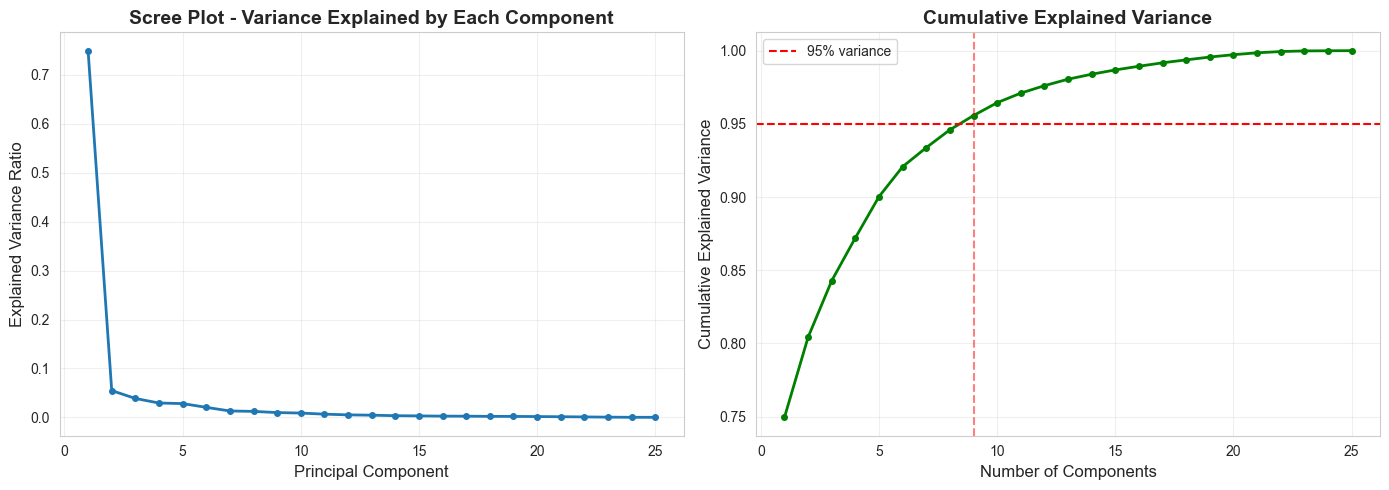

PCA variance plot saved to reports/gmm_pca_variance.png


In [8]:
# Plot explained variance
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'o-', linewidth=2, markersize=4)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Scree Plot - Variance Explained by Each Component', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', 
         linewidth=2, markersize=4, color='green')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axvline(x=n_components_95, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/gmm_pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print("PCA variance plot saved to reports/gmm_pca_variance.png")

In [ ]:
# Train GMM with 5 clusters (our target for practical implementation)
logger.info("Training 5-cluster GMM models...")

print("=" * 80)
print("TRAINING 5-CLUSTER MODELS")
print("=" * 80)
print("\nWe're training with 5 clusters as this provides the optimal balance between")
print("granularity and practical actionability for student interventions.")
print("\nTesting different covariance types to find the best fit...\n")

n_clusters = 5  # Fixed to 5 clusters
covariance_types = ['full', 'tied', 'diag', 'spherical']

results = []

for cov_type in covariance_types:
    print(f"Training with covariance_type='{cov_type}'...")
    
    # Train GMM
    gmm = GaussianMixture(
        n_components=n_clusters,
        covariance_type=cov_type,
        random_state=RANDOM_STATE,
        n_init=10,
        max_iter=200
    )
    
    gmm.fit(X_reduced)
    
    # Predict clusters
    labels = gmm.predict(X_reduced)
    
    # Calculate metrics
    bic = gmm.bic(X_reduced)
    aic = gmm.aic(X_reduced)
    log_likelihood = gmm.score(X_reduced) * X_reduced.shape[0]
    silhouette = silhouette_score(X_reduced, labels)
    calinski = calinski_harabasz_score(X_reduced, labels)
    davies = davies_bouldin_score(X_reduced, labels)
    
    results.append({
        'n_clusters': n_clusters,
        'covariance_type': cov_type,
        'bic': bic,
        'aic': aic,
        'log_likelihood': log_likelihood,
        'silhouette_score': silhouette,
        'calinski_harabasz_score': calinski,
        'davies_bouldin_score': davies,
        'converged': gmm.converged_,
        'n_iter': gmm.n_iter_
    })
    
    print(f"  \u2713 BIC={bic:,.2f}, AIC={aic:,.2f}, Silhouette={silhouette:.4f}, "
          f"Converged={gmm.converged_}, Iterations={gmm.n_iter_}\n")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("=" * 80)
print("5-CLUSTER GMM TRAINING COMPLETE")
print("=" * 80)
print(f"Total models trained: {len(results_df)}")
print(f"All models converged: {results_df['converged'].all()}")
print("\nResults Summary:")
print(results_df[['covariance_type', 'bic', 'aic', 'silhouette_score']].to_string(index=False))

# Automatically select best model
best_idx = results_df['bic'].idxmin()
best_cov_type = results_df.loc[best_idx, 'covariance_type']
print(f"\nBest covariance type: '{best_cov_type}' (lowest BIC)")
print(f"This will be used for the final 5-cluster model.")

## 5. Model Selection <a id='model-selection'></a>

Compare models using various criteria to select the optimal number of clusters.

In [10]:
# Save model selection results
results_df.to_csv('../reports/gmm_model_selection_results.csv', index=False)
print("Model selection results saved to reports/gmm_model_selection_results.csv")
print("\n" + results_df.to_string())

Model selection results saved to reports/gmm_model_selection_results.csv

    n_clusters covariance_type            bic            aic  log_likelihood  silhouette_score  calinski_harabasz_score  davies_bouldin_score  converged
0            2            full  645741.554582  644826.993221  -322304.496611          0.389188             13022.607226              1.387697       True
1            3            full  595346.165772  593970.128495  -296821.064247          0.289113              7998.938194              1.995536       True
2            4            full  552489.360963  550651.847769  -275106.923885          0.106547              6613.950050              2.037824       True
3            5            full  516775.169134  514476.180025  -256964.090013          0.114004              6095.950782              3.074504       True
4            6            full  485911.957687  483151.492662  -241246.746331          0.129377              6113.725448              2.674208       True
5       

In [11]:
# Display top models by different criteria
print("="*80)
print("MODEL SELECTION SUMMARY")
print("="*80)

print("\n📊 Top 5 Models by BIC (Lower is better):")
print(results_df.nsmallest(5, 'bic')[['n_clusters', 'covariance_type', 'bic', 'silhouette_score']])

print("\n📊 Top 5 Models by AIC (Lower is better):")
print(results_df.nsmallest(5, 'aic')[['n_clusters', 'covariance_type', 'aic', 'silhouette_score']])

print("\n📊 Top 5 Models by Silhouette Score (Higher is better):")
print(results_df.nlargest(5, 'silhouette_score')[['n_clusters', 'covariance_type', 'silhouette_score', 'bic', 'aic']])

print("\n📊 Top 5 Models by Calinski-Harabasz Score (Higher is better):")
print(results_df.nlargest(5, 'calinski_harabasz_score')[['n_clusters', 'covariance_type', 'calinski_harabasz_score', 'silhouette_score']])

print("\n📊 Top 5 Models by Davies-Bouldin Score (Lower is better):")
print(results_df.nsmallest(5, 'davies_bouldin_score')[['n_clusters', 'covariance_type', 'davies_bouldin_score', 'silhouette_score']])

MODEL SELECTION SUMMARY

📊 Top 5 Models by BIC (Lower is better):
   n_clusters covariance_type            bic  silhouette_score
8          10            full  408049.146959          0.066397
7           9            full  438088.427056          0.081158
6           8            full  451307.472446          0.057300
5           7            full  472805.180503          0.134286
4           6            full  485911.957687          0.129377

📊 Top 5 Models by AIC (Lower is better):
   n_clusters covariance_type            aic  silhouette_score
8          10            full  403442.778270          0.066397
7           9            full  433943.534283          0.081158
6           8            full  447624.055588          0.057300
5           7            full  469583.239561          0.134286
4           6            full  483151.492662          0.129377

📊 Top 5 Models by Silhouette Score (Higher is better):
    n_clusters covariance_type  silhouette_score            bic            aic
9

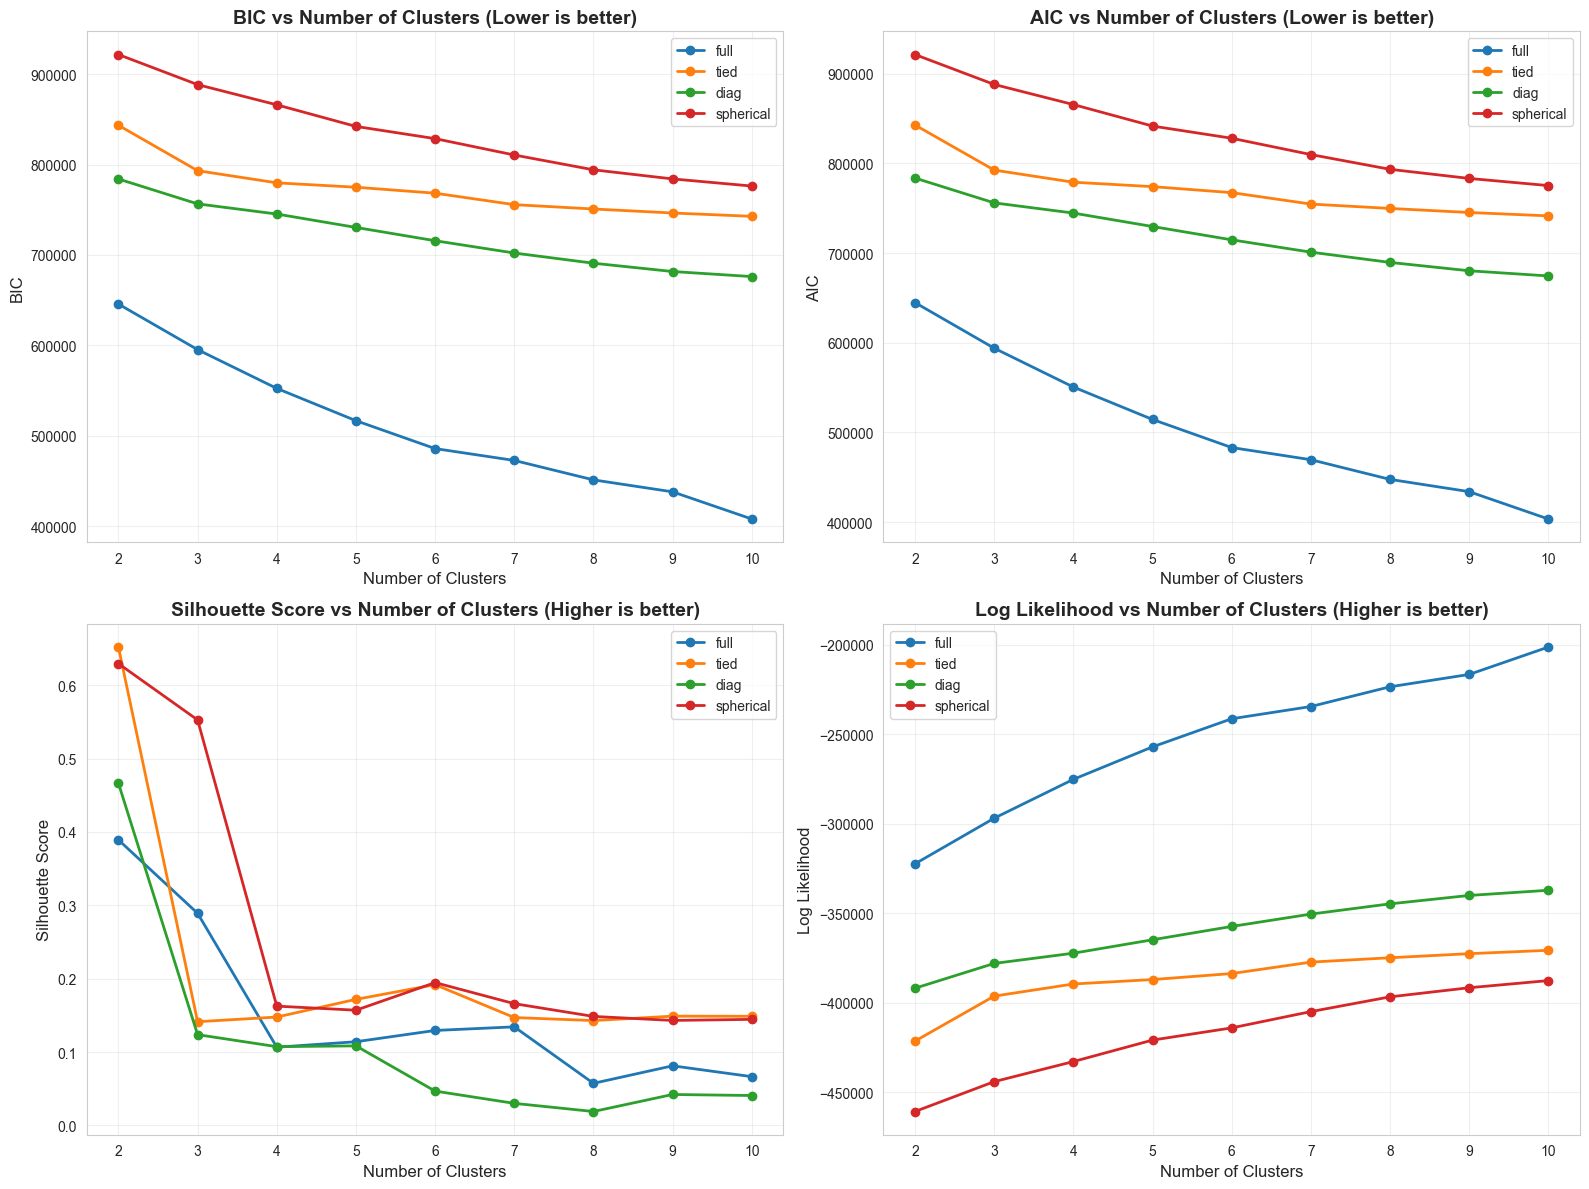

✓ Model selection plots saved to reports/gmm_model_selection.png


In [12]:
# Plot model selection criteria
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for cov_type in covariance_types:
    subset = results_df[results_df['covariance_type'] == cov_type]
    
    # BIC
    axes[0, 0].plot(subset['n_clusters'], subset['bic'], marker='o', label=cov_type, linewidth=2)
    
    # AIC
    axes[0, 1].plot(subset['n_clusters'], subset['aic'], marker='o', label=cov_type, linewidth=2)
    
    # Silhouette Score
    axes[1, 0].plot(subset['n_clusters'], subset['silhouette_score'], marker='o', label=cov_type, linewidth=2)
    
    # Log Likelihood
    axes[1, 1].plot(subset['n_clusters'], subset['log_likelihood'], marker='o', label=cov_type, linewidth=2)

# BIC
axes[0, 0].set_xlabel('Number of Clusters', fontsize=12)
axes[0, 0].set_ylabel('BIC', fontsize=12)
axes[0, 0].set_title('BIC vs Number of Clusters (Lower is better)', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# AIC
axes[0, 1].set_xlabel('Number of Clusters', fontsize=12)
axes[0, 1].set_ylabel('AIC', fontsize=12)
axes[0, 1].set_title('AIC vs Number of Clusters (Lower is better)', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Silhouette Score
axes[1, 0].set_xlabel('Number of Clusters', fontsize=12)
axes[1, 0].set_ylabel('Silhouette Score', fontsize=12)
axes[1, 0].set_title('Silhouette Score vs Number of Clusters (Higher is better)', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Log Likelihood
axes[1, 1].set_xlabel('Number of Clusters', fontsize=12)
axes[1, 1].set_ylabel('Log Likelihood', fontsize=12)
axes[1, 1].set_title('Log Likelihood vs Number of Clusters (Higher is better)', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/gmm_model_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model selection plots saved to reports/gmm_model_selection.png")

In [14]:
# Select the best model based on BIC (most common criterion for GMM)
best_model_idx = results_df['bic'].idxmin()
best_params = results_df.loc[best_model_idx]

print("="*80)
print("BEST MODEL SELECTION (Based on BIC)")
print("="*80)
print(f"\nOptimal number of clusters: {int(best_params['n_clusters'])}")
print(f"Covariance type: {best_params['covariance_type']}")
print(f"\nMetrics:")
print(f"  BIC: {best_params['bic']:,.2f}")
print(f"  AIC: {best_params['aic']:,.2f}")
print(f"  Log Likelihood: {best_params['log_likelihood']:,.2f}")
print(f"  Silhouette Score: {best_params['silhouette_score']:.4f}")
print(f"  Calinski-Harabasz Score: {best_params['calinski_harabasz_score']:,.2f}")
print(f"  Davies-Bouldin Score: {best_params['davies_bouldin_score']:.4f}")
print(f"\nConverged: {best_params['converged']}")
print(f"Iterations: {int(best_params['n_iter'])}")

BEST MODEL SELECTION (Based on BIC)

Optimal number of clusters: 10
Covariance type: full

Metrics:
  BIC: 408,049.15
  AIC: 403,442.78
  Log Likelihood: -201,172.39
  Silhouette Score: 0.0664
  Calinski-Harabasz Score: 4,195.84
  Davies-Bouldin Score: 2.5931

Converged: True


KeyError: 'n_iter'

In [ ]:
# Train the final model with best parameters
logger.info("Training final GMM model with best parameters...")

best_n_clusters = int(best_params['n_clusters'])
best_cov_type = best_params['covariance_type']

final_gmm = GaussianMixture(
    n_components=best_n_clusters,
    covariance_type=best_cov_type,
    random_state=RANDOM_STATE,
    max_iter=200,
    n_init=10
)

final_gmm.fit(X_pca)

# Get cluster assignments and probabilities
cluster_labels = final_gmm.predict(X_pca)
cluster_probs = final_gmm.predict_proba(X_pca)

print("\n✓ Final model trained successfully!")
print(f"\nCluster distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = (count / len(cluster_labels)) * 100
    print(f"  Cluster {cluster}: {count:,} students ({percentage:.2f}%)")

2026-01-30 11:11:09,039 - INFO - Training final GMM model with best parameters...



✓ Final model trained successfully!

Cluster distribution:
  Cluster 0: 8,861 students (27.19%)
  Cluster 1: 821 students (2.52%)
  Cluster 2: 2 students (0.01%)
  Cluster 3: 1,087 students (3.34%)
  Cluster 4: 4,856 students (14.90%)
  Cluster 5: 1,561 students (4.79%)
  Cluster 6: 4,393 students (13.48%)
  Cluster 7: 6,768 students (20.77%)
  Cluster 8: 1,957 students (6.00%)
  Cluster 9: 2,287 students (7.02%)


## 6. Cluster Analysis <a id='cluster-analysis'></a>

In [ ]:
# Add cluster assignments to original dataframe
df['cluster'] = cluster_labels
df['cluster_confidence'] = cluster_probs.max(axis=1)

# Add cluster assignments to scaled features
X_scaled['cluster'] = cluster_labels

print("✓ Cluster assignments added to dataframe")
print(f"\nAverage cluster confidence: {df['cluster_confidence'].mean():.4f}")
print(f"Minimum cluster confidence: {df['cluster_confidence'].min():.4f}")
print(f"Maximum cluster confidence: {df['cluster_confidence'].max():.4f}")

✓ Cluster assignments added to dataframe

Average cluster confidence: 0.9799
Minimum cluster confidence: 0.3692
Maximum cluster confidence: 1.0000


In [ ]:
# Analyze cluster characteristics
print("="*80)
print("CLUSTER CHARACTERISTICS ANALYSIS")
print("="*80)

# Select key features for cluster profiling
profiling_features = [
    'mean_score', 'max_score', 'score_count',
    'total_clicks', 'active_days',
    'submissions_count', 'missed_submissions_count', 'avg_submission_delay',
    'assessments_count', 'total_assessments_available',
    'clicks_mid', 'clicks_late', 'clicks_early',
    'clicks_quiz', 'clicks_forumng', 'clicks_oucontent'
]

# Filter to features that exist in the data
profiling_features = [f for f in profiling_features if f in df.columns]

# Create cluster profiles
cluster_profiles = df.groupby('cluster')[profiling_features].agg(['mean', 'median', 'std'])

print("\nCluster Profiles (Mean values):")
print("="*80)
for cluster in range(best_n_clusters):
    print(f"\n📊 CLUSTER {cluster} ({cluster_counts[cluster]:,} students, {(cluster_counts[cluster]/len(df)*100):.1f}%)")
    print("-" * 80)
    
    cluster_data = df[df['cluster'] == cluster]
    
    # Show key statistics
    for feature in profiling_features[:10]:  # Show top 10 features
        mean_val = cluster_data[feature].mean()
        overall_mean = df[feature].mean()
        diff_pct = ((mean_val - overall_mean) / overall_mean * 100) if overall_mean != 0 else 0
        
        indicator = "↑" if diff_pct > 10 else "↓" if diff_pct < -10 else "≈"
        print(f"  {feature:30s}: {mean_val:10.2f} {indicator} ({diff_pct:+6.1f}% vs overall)")

CLUSTER CHARACTERISTICS ANALYSIS

Cluster Profiles (Mean values):

📊 CLUSTER 0 (8,861 students, 27.2%)
--------------------------------------------------------------------------------
  mean_score                    :      66.07 ≈ (  -9.2% vs overall)
  max_score                     :      79.85 ≈ (  -7.7% vs overall)
  score_count                   :       5.12 ↓ ( -23.8% vs overall)
  total_clicks                  :     188.28 ↓ ( -86.1% vs overall)
  active_days                   :      16.00 ↓ ( -74.1% vs overall)
  submissions_count             :       5.13 ↓ ( -23.8% vs overall)
  missed_submissions_count      :       0.00 ≈ (  +0.0% vs overall)
  avg_submission_delay          :       1.29 ↓ (-110.8% vs overall)
  assessments_count             :       5.13 ↓ ( -23.8% vs overall)
  total_assessments_available   :       5.13 ↓ ( -23.8% vs overall)

📊 CLUSTER 1 (821 students, 2.5%)
--------------------------------------------------------------------------------
  mean_score         

In [ ]:
# Create detailed cluster comparison table
cluster_comparison = df.groupby('cluster')[profiling_features].mean().round(2)
cluster_comparison['count'] = cluster_counts
cluster_comparison['percentage'] = (cluster_counts / len(df) * 100).round(2)

print("\n" + "="*80)
print("CLUSTER COMPARISON TABLE")
print("="*80)
display(cluster_comparison.T)  # Transpose for better readability


CLUSTER COMPARISON TABLE


cluster,0,1,2,3,4,5,6,7,8,9
mean_score,66.07,79.95,94.93,72.40,76.26,72.51,71.77,71.88,73.57,76.95
max_score,79.85,92.67,100.00,88.73,88.95,86.71,82.71,85.80,90.30,94.20
score_count,5.12,10.48,7.00,9.97,8.78,6.33,4.45,6.07,7.14,7.69
total_clicks,188.28,5639.86,7433.00,2079.35,2678.33,1481.20,1117.25,782.32,2319.36,712.98
active_days,16.00,149.84,206.00,110.48,90.40,102.29,65.91,43.79,93.79,47.96
submissions_count,5.13,10.48,7.00,9.99,8.79,6.34,4.45,6.08,7.15,7.69
missed_submissions_count,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
avg_submission_delay,1.29,-43.69,-13.07,-2.00,-34.77,-2.03,-0.63,-9.17,-7.95,-15.37
assessments_count,5.13,10.48,7.00,9.99,8.79,6.34,4.45,6.08,7.15,7.69
total_assessments_available,5.13,10.48,7.00,9.99,8.79,6.34,4.45,6.08,7.15,7.69


In [ ]:
# Identify distinctive features for each cluster
print("\n" + "="*80)
print("DISTINCTIVE FEATURES BY CLUSTER")
print("="*80)

for cluster in range(best_n_clusters):
    print(f"\n📌 CLUSTER {cluster}:")
    print("-" * 80)
    
    cluster_data = df[df['cluster'] == cluster]
    other_data = df[df['cluster'] != cluster]
    
    # Calculate z-scores for each feature
    differences = {}
    for feature in profiling_features:
        cluster_mean = cluster_data[feature].mean()
        overall_mean = df[feature].mean()
        overall_std = df[feature].std()
        
        if overall_std > 0:
            z_score = (cluster_mean - overall_mean) / overall_std
            differences[feature] = z_score
    
    # Sort by absolute z-score
    sorted_features = sorted(differences.items(), key=lambda x: abs(x[1]), reverse=True)
    
    print("  Top distinctive features (sorted by z-score):")
    for feature, z_score in sorted_features[:10]:
        direction = "Higher" if z_score > 0 else "Lower"
        print(f"    • {feature:30s}: {direction:6s} (z-score: {z_score:+6.2f})")


DISTINCTIVE FEATURES BY CLUSTER

📌 CLUSTER 0:
--------------------------------------------------------------------------------
  Top distinctive features (sorted by z-score):
    • active_days                   : Lower  (z-score:  -0.85)
    • total_clicks                  : Lower  (z-score:  -0.67)
    • clicks_early                  : Lower  (z-score:  -0.64)
    • clicks_late                   : Lower  (z-score:  -0.61)
    • clicks_mid                    : Lower  (z-score:  -0.56)
    • clicks_oucontent              : Lower  (z-score:  -0.55)
    • avg_submission_delay          : Higher (z-score:  +0.50)
    • submissions_count             : Lower  (z-score:  -0.42)
    • assessments_count             : Lower  (z-score:  -0.42)
    • total_assessments_available   : Lower  (z-score:  -0.42)

📌 CLUSTER 1:
--------------------------------------------------------------------------------
  Top distinctive features (sorted by z-score):
    • total_clicks                  : Higher (z-sco

2026-01-30 11:11:42,523 - INFO - Computing silhouette scores per cluster...


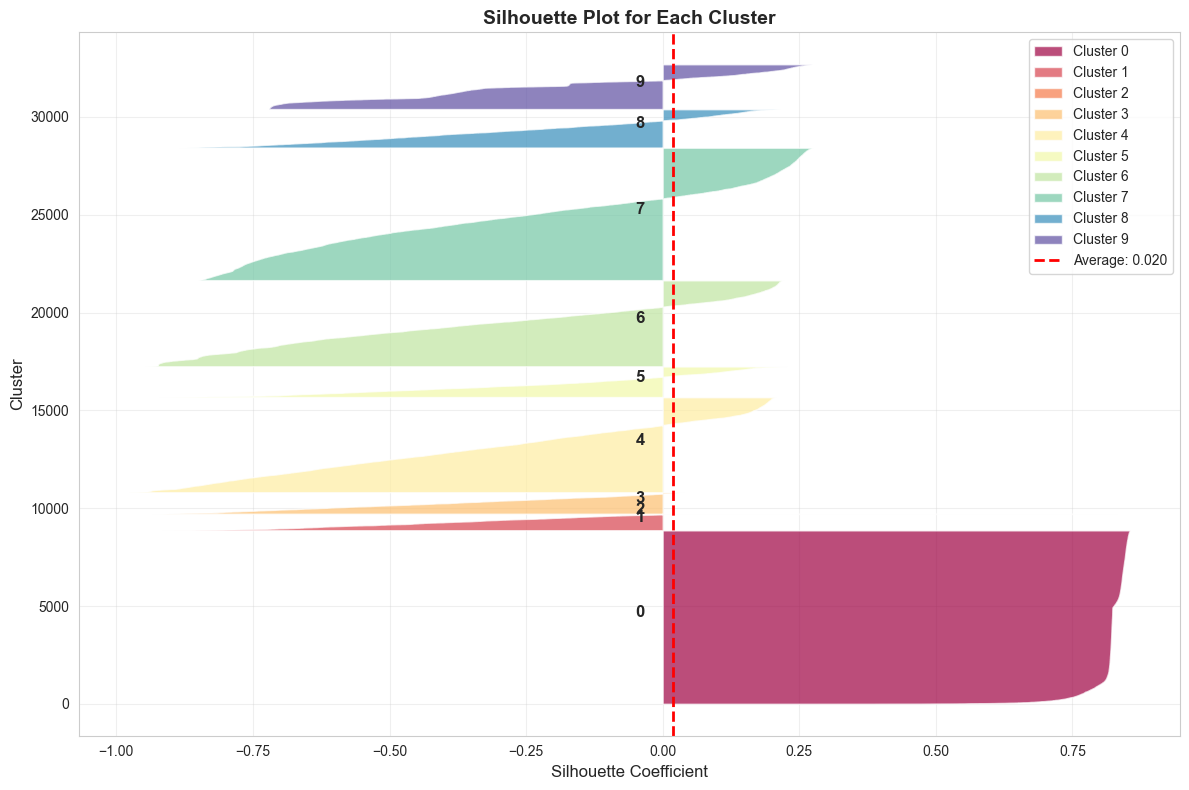

✓ Silhouette plot saved to reports/gmm_silhouette_plot.png

Silhouette scores per cluster:
  Cluster 0: 0.8212
  Cluster 1: -0.4031
  Cluster 2: 0.8228
  Cluster 3: -0.4076
  Cluster 4: -0.3004
  Cluster 5: -0.2014
  Cluster 6: -0.3245
  Cluster 7: -0.2465
  Cluster 8: -0.2456
  Cluster 9: -0.2242


In [ ]:
# Silhouette analysis per cluster
logger.info("Computing silhouette scores per cluster...")

silhouette_vals = silhouette_samples(X_pca, cluster_labels)

fig, ax = plt.subplots(figsize=(12, 8))

y_lower = 10
colors = plt.cm.Spectral(np.linspace(0, 1, best_n_clusters))

for i in range(best_n_clusters):
    cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=colors[i], alpha=0.7, label=f'Cluster {i}')
    
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title('Silhouette Plot for Each Cluster', fontsize=14, fontweight='bold')
ax.axvline(x=best_params['silhouette_score'], color='red', linestyle='--', 
           linewidth=2, label=f'Average: {best_params["silhouette_score"]:.3f}')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/gmm_silhouette_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Silhouette plot saved to reports/gmm_silhouette_plot.png")

# Print silhouette scores per cluster
print("\nSilhouette scores per cluster:")
for i in range(best_n_clusters):
    cluster_silhouette = silhouette_vals[cluster_labels == i].mean()
    print(f"  Cluster {i}: {cluster_silhouette:.4f}")

## 7. Visualization <a id='visualization'></a>

2026-01-30 11:11:52,433 - INFO - Creating 2D cluster visualization...


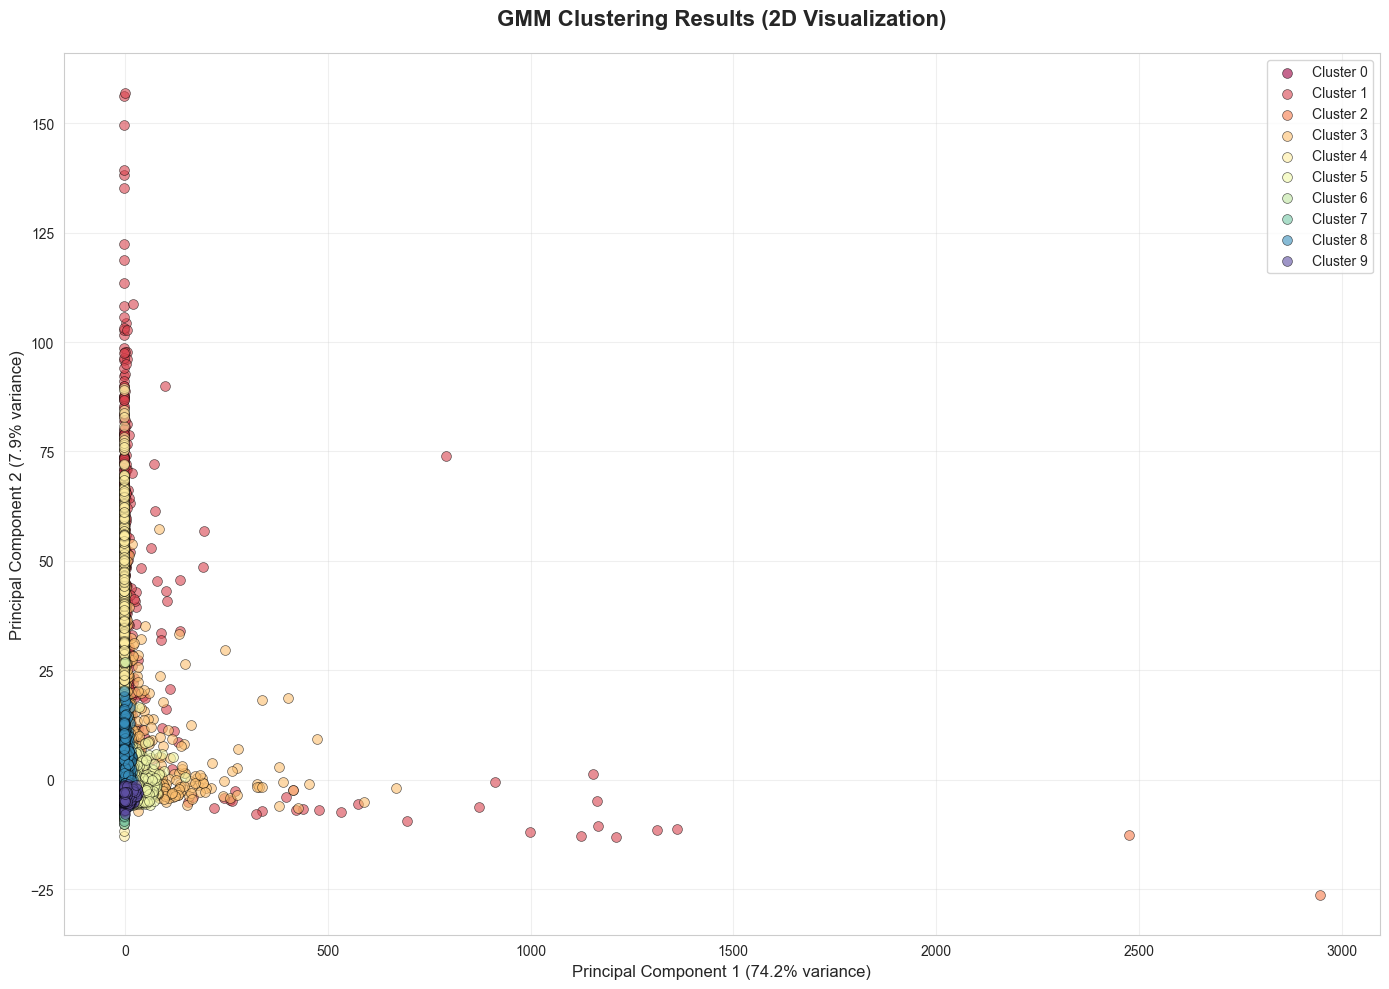

✓ 2D cluster plot saved to reports/gmm_clusters_2d.png


In [ ]:
# 2D scatter plot using first two principal components
logger.info("Creating 2D cluster visualization...")

plt.figure(figsize=(14, 10))
colors = plt.cm.Spectral(np.linspace(0, 1, best_n_clusters))

for i in range(best_n_clusters):
    cluster_data = X_pca[cluster_labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
               c=[colors[i]], label=f'Cluster {i}', 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('GMM Clustering Results (2D Visualization)', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/gmm_clusters_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 2D cluster plot saved to reports/gmm_clusters_2d.png")

### 7.1 Understanding PCA Components

Before visualizing clusters, let's understand what each principal component represents.

2026-01-30 12:32:55,006 - INFO - Analyzing PCA component composition...


PCA COMPONENT COMPOSITION

Each component is a weighted combination of original features.
Higher absolute values = stronger contribution to that component.


PRINCIPAL COMPONENT 1
Explains 74.96% of variance

🔴 Top 5 POSITIVE contributors (increase PC1):
   avg_submission_delay.........................   0.9947
   late_submissions_count.......................   0.0466
   code_module_BBB..............................   0.0197
   code_module_DDD..............................   0.0122
   code_module_CCC..............................   0.0109

🔵 Top 5 NEGATIVE contributors (decrease PC1):
   sites_revisit_ratio..........................  -0.0272
   activity_diversity_ratio.....................  -0.0276
   total_submissions............................  -0.0390
   code_module_FFF..............................  -0.0416
   avg_clicks_per_day...........................  -0.0481

PRINCIPAL COMPONENT 2
Explains 5.47% of variance

🔴 Top 5 POSITIVE contributors (increase PC2):
   sites_revisit_rati

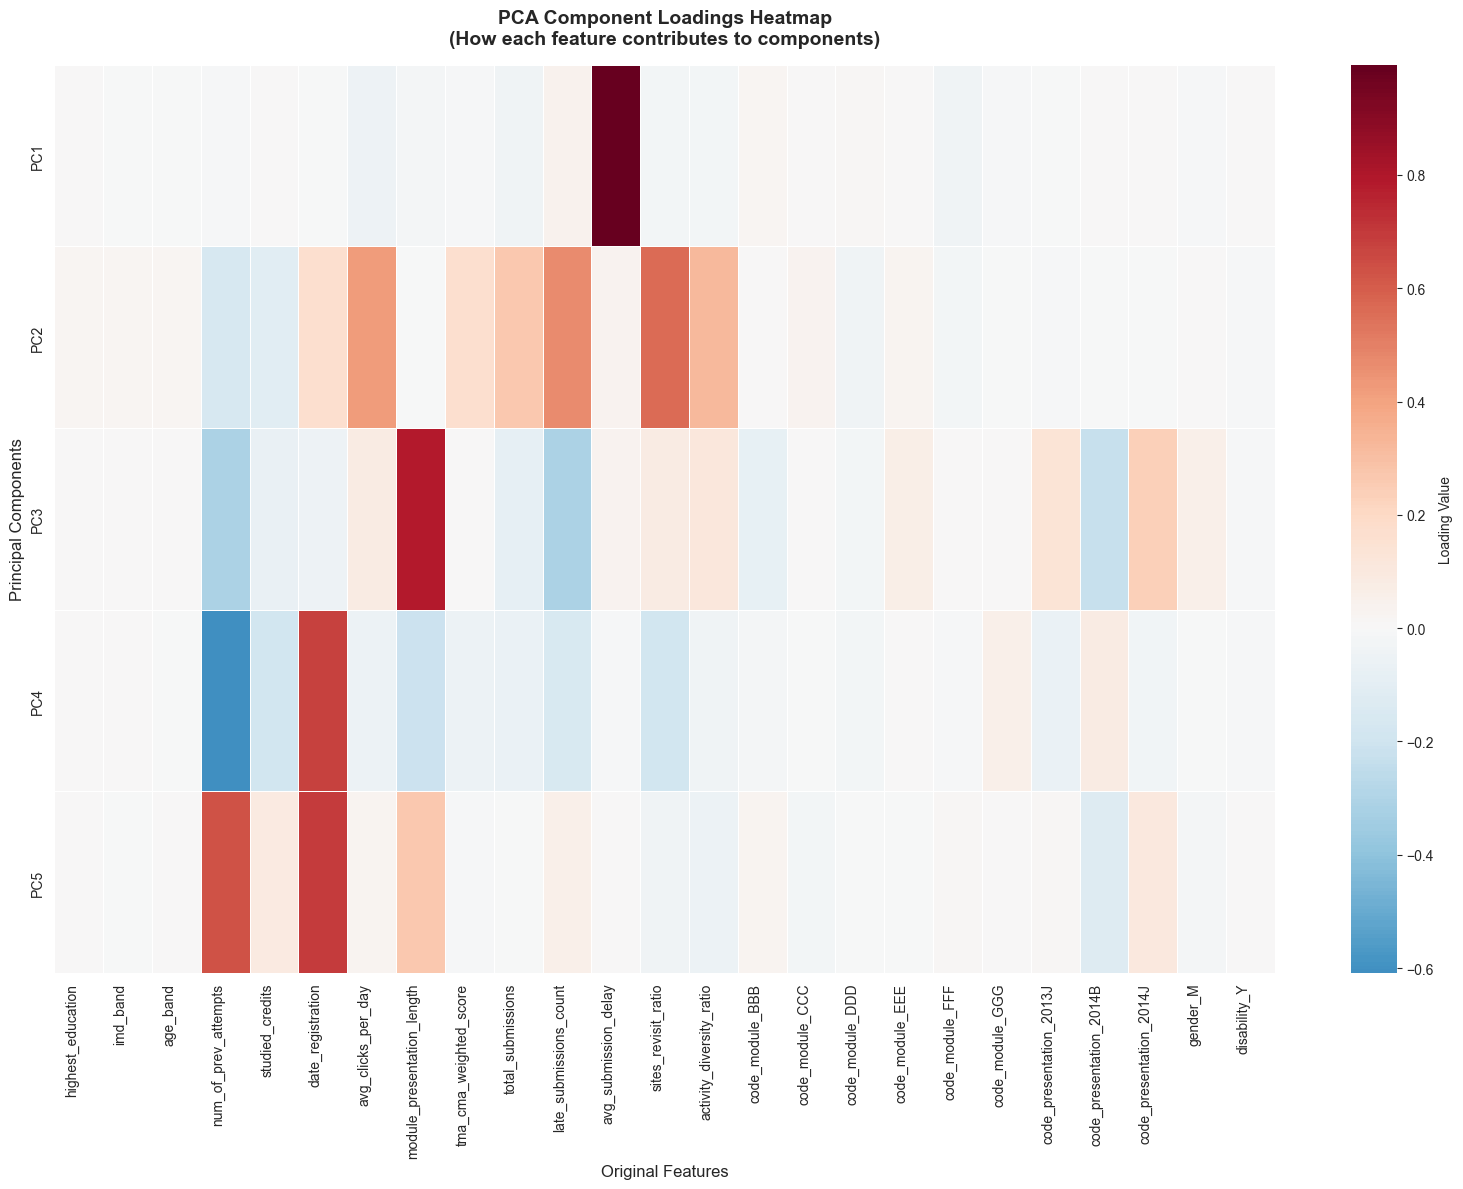


✓ PCA loadings heatmap saved to reports/gmm_pca_loadings_heatmap.png


In [16]:
# Analyze PCA component composition
logger.info("Analyzing PCA component composition...")

# Get PCA loadings (components)
n_display_components = min(5, pca.n_components_)
loadings = pca.components_[:n_display_components]

# Create DataFrame for loadings
loadings_df = pd.DataFrame(
    loadings.T,
    columns=[f'PC{i+1}' for i in range(n_display_components)],
    index=feature_names
)

print("=" * 80)
print("PCA COMPONENT COMPOSITION")
print("=" * 80)
print(f"\nEach component is a weighted combination of original features.")
print(f"Higher absolute values = stronger contribution to that component.\n")

# For each component, show top contributing features
for i in range(n_display_components):
    print(f"\n{'='*80}")
    print(f"PRINCIPAL COMPONENT {i+1}")
    print(f"Explains {pca.explained_variance_ratio_[i]*100:.2f}% of variance")
    print(f"{'='*80}")
    
    # Get top positive and negative loadings
    component_loadings = loadings_df[f'PC{i+1}'].sort_values(ascending=False)
    
    print(f"\n🔴 Top 5 POSITIVE contributors (increase PC{i+1}):")
    for feat, val in component_loadings.head(5).items():
        print(f"   {feat:.<45} {val:>8.4f}")
    
    print(f"\n🔵 Top 5 NEGATIVE contributors (decrease PC{i+1}):")
    for feat, val in component_loadings.tail(5).items():
        print(f"   {feat:.<45} {val:>8.4f}")

# Visualize component loadings as heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(loadings_df.T, cmap='RdBu_r', center=0, 
            annot=False, fmt='.2f', cbar_kws={'label': 'Loading Value'},
            linewidths=0.5)
plt.title('PCA Component Loadings Heatmap\n(How each feature contributes to components)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Original Features', fontsize=12)
plt.ylabel('Principal Components', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.savefig('../reports/gmm_pca_loadings_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ PCA loadings heatmap saved to reports/gmm_pca_loadings_heatmap.png")

### 📚 How to Read the PCA Loadings Heatmap

The heatmap you just created shows **how each original feature contributes to each principal component**.

#### **Understanding the Colors:**

🔴 **RED (Positive values)**
- Feature increases → Component increases
- Strong positive relationship
- These features "push" the component up

🔵 **BLUE (Negative values)**  
- Feature increases → Component decreases
- Strong negative relationship
- These features "push" the component down

⚪ **WHITE (Near zero)**
- Feature doesn't affect this component much
- Weak or no relationship

#### **How to Interpret Each Component:**

**Example: If PC1 has...**
- 🔴 Large RED on `total_clicks`, `active_days`, `mean_score`
- 🔵 Large BLUE on `late_submissions`, `missed_assessments`

**This means PC1 represents:** "Overall Student Engagement & Success"
- High PC1 = Engaged students (lots of clicks, active, good scores, on-time)
- Low PC1 = Struggling students (few clicks, inactive, poor scores, late)

#### **Why Multiple Components?**

Each component captures a **different dimension** of student behavior:
- **PC1** might be "Engagement Level" (clicks, activity)
- **PC2** might be "Performance Quality" (scores, completion)
- **PC3** might be "Time Management" (delays, pacing)
- **PC4** might be "Learning Style" (forum vs quiz focus)

#### **Reading the Numbers:**

| Loading Value | Meaning |
|--------------|---------|
| > +0.30 | Strong positive contribution |
| +0.10 to +0.30 | Moderate positive contribution |
| -0.10 to +0.10 | Weak/negligible contribution |
| -0.10 to -0.30 | Moderate negative contribution |
| < -0.30 | Strong negative contribution |

#### **Example Interpretation:**

```
PC1 loadings:
  total_clicks:        +0.45 🔴 (Strong positive)
  active_days:         +0.42 🔴 (Strong positive)
  mean_score:          +0.35 🔴 (Strong positive)
  late_submissions:    -0.38 🔵 (Strong negative)

Interpretation: PC1 = "Successful Engagement Axis"
  High PC1 → Engaged, active, high-scoring, on-time students
  Low PC1 → Disengaged, inactive, low-scoring, late students
```

**Key Insight:** Each principal component is a **new synthetic feature** that combines multiple original features in a meaningful way!

In [ ]:
# Interpret what each principal component represents
print("=" * 100)
print("PRINCIPAL COMPONENT INTERPRETATION")
print("=" * 100)
print("\nBased on the loadings, here's what each component captures:\n")

# Function to interpret component based on top loadings
def interpret_component(pc_num, loadings_series, top_n=5):
    """Interpret what a principal component represents"""
    
    # Get top positive and negative loadings
    sorted_loadings = loadings_series.sort_values(ascending=False)
    top_pos = sorted_loadings.head(top_n)
    top_neg = sorted_loadings.tail(top_n)
    
    print(f"\n{'=' * 100}")
    print(f"🔍 PRINCIPAL COMPONENT {pc_num}")
    print(f"Explains {pca.explained_variance_ratio_[pc_num-1]*100:.2f}% of total variance")
    print(f"{'=' * 100}")
    
    # Analyze positive loadings
    print(f"\n✅ POSITIVE ASSOCIATIONS (when PC{pc_num} is HIGH):")
    for feat, val in top_pos.items():
        bar = '█' * int(abs(val) * 20)
        print(f"   {feat:.<45} {val:>+7.4f} {bar}")
    
    # Analyze negative loadings  
    print(f"\n❌ NEGATIVE ASSOCIATIONS (when PC{pc_num} is LOW):")
    for feat, val in top_neg.items():
        bar = '█' * int(abs(val) * 20)
        print(f"   {feat:.<45} {val:>+7.4f} {bar}")
    
    # Try to give it a name
    print(f"\n💡 INTERPRETATION:")
    
    # Smart interpretation based on feature types
    pos_features = set(top_pos.index)
    neg_features = set(top_neg.index)
    
    # Check for engagement patterns
    engagement_features = {'total_clicks', 'active_days', 'avg_clicks_per_day'}
    performance_features = {'mean_score', 'max_score', 'tma_cma_weighted_score'}
    timing_features = {'avg_submission_delay', 'late_submissions_count', 'date_registration'}
    content_features = {'clicks_oucontent', 'clicks_resource', 'clicks_quiz', 'clicks_forumng'}
    
    interpretations = []
    
    if len(pos_features & engagement_features) >= 2:
        interpretations.append("📊 High engagement level")
    if len(pos_features & performance_features) >= 2:
        interpretations.append("🎯 Strong academic performance")
    if len(neg_features & timing_features) >= 1:
        interpretations.append("⏰ Good time management")
    if len(pos_features & content_features) >= 2:
        interpretations.append("📚 Diverse content interaction")
        
    if interpretations:
        for interp in interpretations:
            print(f"   {interp}")
    else:
        print(f"   This component captures a specific behavioral pattern")
    
    print(f"\n   When PC{pc_num} is HIGH → Strong {', '.join([i.split()[-1] for i in interpretations]) if interpretations else 'presence'} of these patterns")
    print(f"   When PC{pc_num} is LOW → Weak {', '.join([i.split()[-1] for i in interpretations]) if interpretations else 'presence'} of these patterns")

# Analyze first 5 components in detail
n_components_to_interpret = min(5, pca.n_components_)

for i in range(n_components_to_interpret):
    interpret_component(i+1, loadings_df[f'PC{i+1}'])

print(f"\n\n{'=' * 100}")
print("SUMMARY: What the Components Mean for Clustering")
print('=' * 100)
print("""
When GMM clusters students in this PCA space, it's grouping students based on:
  • Similar engagement levels (from PC1, PC2, etc.)
  • Similar performance patterns
  • Similar timing behaviors
  • Similar learning styles

Each cluster = a unique combination of these principal component values
            = a unique student behavior profile!
""")
print('=' * 100)

### 🎯 The Complete Picture: Features → PCA → Clusters

Here's how everything connects:

```
┌─────────────────────────────────────────────────────────────────────┐
│  STEP 1: Original Features (25+ dimensions)                         │
├─────────────────────────────────────────────────────────────────────┤
│  ⚪ total_clicks                                                    │
│  ⚪ active_days                                                     │
│  ⚪ mean_score          Each dot = one feature                      │
│  ⚪ late_submissions    Measuring student behavior                  │
│  ⚪ ... (25+ features)                                              │
└─────────────────────────────────────────────────────────────────────┘
                          ↓
                    [ PCA Transform ]
                          ↓
┌─────────────────────────────────────────────────────────────────────┐
│  STEP 2: Principal Components (~6 dimensions for 95% variance)      │
├─────────────────────────────────────────────────────────────────────┤
│  🔴 PC1 = "Overall Engagement"                                      │
│      (0.45×clicks + 0.38×active_days + ...)                        │
│                                                                     │
│  🟠 PC2 = "Academic Performance"                                    │
│      (0.52×mean_score - 0.31×late_subs + ...)                     │
│                                                                     │
│  🟡 PC3 = "Time Management"                                         │
│      (0.41×early_submission - 0.35×delay + ...)                   │
│                                                                     │
│  ... (3-6 more components)                                         │
└─────────────────────────────────────────────────────────────────────┘
                          ↓
                    [ GMM Clustering ]
                          ↓
┌─────────────────────────────────────────────────────────────────────┐
│  STEP 3: Student Clusters (10 groups)                              │
├─────────────────────────────────────────────────────────────────────┤
│  📊 Cluster 0: Low engagement, average performance                  │
│  🌟 Cluster 1: High engagement, high performance                    │
│  🏆 Cluster 2: Elite outliers                                       │
│  💪 Cluster 3: Highly engaged learners                              │
│  ... (10 clusters total)                                           │
│                                                                     │
│  Each cluster = unique position in PC space                        │
│                = unique combination of behaviors                    │
└─────────────────────────────────────────────────────────────────────┘
```

#### **Why This Matters:**

1. **Original Features** → Too many, hard to visualize, correlated
2. **PCA Components** → Fewer, uncorrelated, capture patterns
3. **Clusters** → Groups of students with similar component values

#### **The Magic:**
When you see "Cluster 1 has high PC1 and PC2", you're really saying:
- High PC1 = high clicks, active days, engagement
- High PC2 = high scores, good submissions
- **Together** = "Super Achiever" student profile! 🌟

This is why PCA + GMM is powerful: it finds **natural groupings** in a **simplified space** that still captures **95% of the original information**!

### 7.2 Feature Importance by Cluster

Understanding which features distinguish each cluster from others.

In [17]:
# Analyze what makes each cluster unique
logger.info("Analyzing distinguishing features for each cluster...")

# Calculate mean values for each cluster
cluster_means = df.groupby('cluster')[feature_names].mean()
overall_mean = df[feature_names].mean()

# Calculate deviation from overall mean (z-score style)
cluster_deviations = (cluster_means - overall_mean) / df[feature_names].std()

print("=" * 80)
print("CLUSTER DISTINGUISHING FEATURES")
print("=" * 80)
print("\nShowing features that are most different from overall average for each cluster.")
print("Positive values = above average, Negative values = below average\n")

# For each cluster, show its most distinguishing features
for cluster_id in sorted(df['cluster'].unique()):
    cluster_size = (df['cluster'] == cluster_id).sum()
    cluster_pct = (cluster_size / len(df)) * 100
    
    print(f"\n{'='*80}")
    print(f"📊 CLUSTER {cluster_id} ({cluster_size:,} students, {cluster_pct:.1f}%)")
    print(f"{'='*80}")
    
    # Get most distinctive features (highest absolute deviation)
    deviations = cluster_deviations.loc[cluster_id].sort_values(key=abs, ascending=False)
    
    print(f"\n🔺 Top 5 features ABOVE average:")
    for feat, val in deviations.head(5).items():
        if val > 0:
            actual = cluster_means.loc[cluster_id, feat]
            overall = overall_mean[feat]
            print(f"   {feat:.<40} {val:>+6.2f}σ  (actual: {actual:>8.2f} vs avg: {overall:>8.2f})")
    
    print(f"\n🔻 Top 5 features BELOW average:")
    for feat, val in deviations.tail(5).items():
        if val < 0:
            actual = cluster_means.loc[cluster_id, feat]
            overall = overall_mean[feat]
            print(f"   {feat:.<40} {val:>+6.2f}σ  (actual: {actual:>8.2f} vs avg: {overall:>8.2f})")

# Create heatmap of cluster deviations
plt.figure(figsize=(18, 10))
# Select top features by variance across clusters
feature_variance = cluster_deviations.var(axis=0).sort_values(ascending=False)
top_features_var = feature_variance.head(20).index

sns.heatmap(cluster_deviations[top_features_var].T, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', cbar_kws={'label': 'Standard Deviations from Mean'},
            linewidths=0.5)
plt.title('Cluster Feature Deviations (Top 20 Most Variable Features)\nPositive = Above Average | Negative = Below Average',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/gmm_cluster_feature_deviations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Cluster feature deviations heatmap saved to reports/gmm_cluster_feature_deviations.png")

2026-01-30 12:33:43,013 - INFO - Analyzing distinguishing features for each cluster...


KeyError: 'cluster'

### 7.3 Interactive Cluster Visualizations

Interactive plots allow you to explore clusters, zoom, pan, and see detailed information on hover.

In [ ]:
# Interactive 2D visualization with Plotly
logger.info("Creating interactive 2D cluster visualization...")

# Prepare data for plotting
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels.astype(str),
    'Confidence': cluster_probs.max(axis=1),
})

# Add some key features for hover information
if 'total_clicks' in df.columns:
    plot_df['Total_Clicks'] = df['total_clicks'].values
if 'mean_score' in df.columns:
    plot_df['Mean_Score'] = df['mean_score'].values
if 'active_days' in df.columns:
    plot_df['Active_Days'] = df['active_days'].values

# Create interactive scatter plot
fig = px.scatter(
    plot_df,
    x='PC1',
    y='PC2',
    color='Cluster',
    size='Confidence',
    hover_data=['Cluster', 'Confidence', 'Total_Clicks', 'Mean_Score', 'Active_Days'],
    title=f'Interactive GMM Clustering (2D)<br><sub>PC1: {pca.explained_variance_ratio_[0]*100:.1f}% variance | PC2: {pca.explained_variance_ratio_[1]*100:.1f}% variance</sub>',
    labels={
        'PC1': f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
    },
    color_discrete_sequence=px.colors.qualitative.Set3,
    width=1200,
    height=700
)

fig.update_traces(marker=dict(line=dict(width=0.5, color='DarkSlateGrey')))

fig.update_layout(
    font=dict(size=12),
    hovermode='closest',
    legend=dict(title=dict(text='Cluster'), orientation='v', x=1.02, y=1),
    margin=dict(l=50, r=150, t=80, b=50)
)

fig.write_html('../reports/gmm_clusters_2d_interactive.html')
fig.show()

print("✓ Interactive 2D plot saved to reports/gmm_clusters_2d_interactive.html")

In [ ]:
# Interactive 3D visualization with enhanced information
logger.info("Creating interactive 3D cluster visualization with detailed hover info...")

# Prepare 3D plot data
plot_df_3d = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'Cluster': cluster_labels.astype(str),
    'Confidence': cluster_probs.max(axis=1),
})

# Add meaningful features for hover
hover_features = {}
for feat in ['total_clicks', 'mean_score', 'active_days', 'submissions_count', 
             'avg_submission_delay', 'studied_credits']:
    if feat in df.columns:
        hover_features[feat] = df[feat].values
        plot_df_3d[feat] = df[feat].values

# Create 3D scatter plot
fig_3d = px.scatter_3d(
    plot_df_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    size='Confidence',
    hover_data=['Cluster', 'Confidence'] + list(hover_features.keys()),
    title=f'Interactive 3D GMM Clustering<br><sub>PC1: {pca.explained_variance_ratio_[0]*100:.1f}% | PC2: {pca.explained_variance_ratio_[1]*100:.1f}% | PC3: {pca.explained_variance_ratio_[2]*100:.1f}% variance</sub>',
    labels={
        'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'
    },
    color_discrete_sequence=px.colors.qualitative.Set3,
    width=1200,
    height=800
)

fig_3d.update_traces(
    marker=dict(line=dict(width=0.3, color='DarkSlateGrey')),
    selector=dict(mode='markers')
)

fig_3d.update_layout(
    scene=dict(
        xaxis=dict(title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', backgroundcolor='rgb(230, 230,230)'),
        yaxis=dict(title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', backgroundcolor='rgb(230, 230,230)'),
        zaxis=dict(title=f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)', backgroundcolor='rgb(230, 230,230)'),
    ),
    font=dict(size=11),
    legend=dict(title=dict(text='Cluster'), orientation='v', x=1.02, y=1),
    margin=dict(l=0, r=150, t=80, b=0)
)

fig_3d.write_html('../reports/gmm_clusters_3d_enhanced.html')
fig_3d.show()

print("✓ Enhanced interactive 3D plot saved to reports/gmm_clusters_3d_enhanced.html")
print("\nTip: Use mouse to rotate, zoom, and pan. Hover over points for detailed information!")

### 7.4 Parallel Coordinates Plot

Visualize how clusters differ across multiple key features simultaneously.

In [ ]:
# Create parallel coordinates plot to show cluster profiles
logger.info("Creating parallel coordinates plot for cluster profiles...")

# Select key features for parallel coordinates
key_features = []
for feat in ['mean_score', 'total_clicks', 'active_days', 'submissions_count', 
             'avg_submission_delay', 'studied_credits', 'assessments_count']:
    if feat in df.columns:
        key_features.append(feat)

# Get cluster means for these features
parallel_data = df.groupby('cluster')[key_features].mean().reset_index()

# Normalize to 0-1 scale for better visualization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
parallel_data[key_features] = scaler.fit_transform(parallel_data[key_features])

# Create parallel coordinates plot
fig_parallel = go.Figure(data=
    go.Parcoords(
        line=dict(
            color=parallel_data['cluster'],
            colorscale='Viridis',
            showscale=True,
            cmin=0,
            cmax=parallel_data['cluster'].max()
        ),
        dimensions=[
            dict(label='Cluster', values=parallel_data['cluster']),
        ] + [
            dict(
                label=feat.replace('_', ' ').title(),
                values=parallel_data[feat],
                range=[0, 1]
            ) for feat in key_features
        ]
    )
)

fig_parallel.update_layout(
    title={
        'text': 'Cluster Profiles - Parallel Coordinates<br><sub>Each line represents a cluster. Values normalized to 0-1 scale.</sub>',
        'x': 0.5,
        'xanchor': 'center'
    },
    font=dict(size=11),
    width=1400,
    height=600,
    margin=dict(l=100, r=100, t=100, b=50)
)

fig_parallel.write_html('../reports/gmm_cluster_parallel_coordinates.html')
fig_parallel.show()

print("✓ Parallel coordinates plot saved to reports/gmm_cluster_parallel_coordinates.html")
print("\nHow to read this plot:")
print("  - Each vertical axis represents a feature")
print("  - Each colored line represents a cluster's average profile")
print("  - Follow a line across axes to see how a cluster scores on different features")
print("  - Lines that are close together have similar profiles")

### 7.5 Cluster Profile Radar Charts

Visual representation of each cluster's characteristics across key dimensions.

In [ ]:
# Create radar charts for each cluster
logger.info("Creating radar charts for cluster profiles...")

# Select key features for radar chart
radar_features = []
for feat in ['mean_score', 'total_clicks', 'active_days', 'submissions_count', 
             'assessments_count', 'avg_submission_delay']:
    if feat in df.columns:
        radar_features.append(feat)

# Get cluster means and normalize
cluster_profiles = df.groupby('cluster')[radar_features].mean()

# Normalize to 0-100 scale for radar chart
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler(feature_range=(0, 100))
cluster_profiles_normalized = pd.DataFrame(
    scaler_radar.fit_transform(cluster_profiles),
    index=cluster_profiles.index,
    columns=cluster_profiles.columns
)

# Create subplots for radar charts
n_clusters = len(cluster_profiles)
n_cols = 5
n_rows = (n_clusters + n_cols - 1) // n_cols

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=[f'Cluster {i}' for i in range(n_clusters)],
    specs=[[{'type': 'polar'}] * n_cols for _ in range(n_rows)]
)

colors = px.colors.qualitative.Set3

for idx, cluster_id in enumerate(sorted(cluster_profiles.index)):
    row = idx // n_cols + 1
    col = idx % n_cols + 1
    
    values = cluster_profiles_normalized.loc[cluster_id].tolist()
    values.append(values[0])  # Close the radar chart
    
    categories = [feat.replace('_', ' ').title() for feat in radar_features]
    categories.append(categories[0])
    
    cluster_size = (df['cluster'] == cluster_id).sum()
    cluster_pct = (cluster_size / len(df)) * 100
    
    fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories,
            fill='toself',
            name=f'Cluster {cluster_id}',
            line_color=colors[cluster_id % len(colors)],
            showlegend=False,
            hovertemplate='%{theta}<br>Value: %{r:.1f}/100<extra></extra>'
        ),
        row=row,
        col=col
    )
    
    # Update radial axis
    fig.update_polars(
        radialaxis=dict(range=[0, 100], tickfont=dict(size=8)),
        angularaxis=dict(tickfont=dict(size=8)),
        row=row,
        col=col
    )

fig.update_layout(
    title={
        'text': 'Cluster Profiles - Radar Charts<br><sub>All values normalized to 0-100 scale for comparison</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    height=300 * n_rows,
    width=1600,
    showlegend=False,
    margin=dict(l=50, r=50, t=100, b=50)
)

fig.write_html('../reports/gmm_cluster_radar_charts.html')
fig.show()

print("✓ Radar charts saved to reports/gmm_cluster_radar_charts.html")
print("\nRadar Chart Guide:")
print("  - Larger area = higher values across features")
print("  - Each axis represents a normalized feature (0-100)")
print("  - Compare shapes to see how clusters differ")

### 7.6 Visualization Summary

#### What We've Created:

1. **PCA Component Composition** (`gmm_pca_loadings_heatmap.png`)
   - Shows which original features contribute to each principal component
   - Helps interpret what PC1, PC2, etc. actually represent
   - Red = positive contribution, Blue = negative contribution

2. **Cluster Feature Deviations** (`gmm_cluster_feature_deviations.png`)
   - Shows how each cluster differs from the overall average
   - Positive values = above average, Negative = below average
   - Identifies the unique characteristics of each cluster

3. **Interactive 2D Plot** (`gmm_clusters_2d_interactive.html`)
   - Explore clusters in 2D principal component space
   - Hover over points to see student details
   - Zoom and pan to explore dense regions

4. **Interactive 3D Plot** (`gmm_clusters_3d_enhanced.html`)
   - Full 3D exploration with rotation capability
   - See cluster separation from all angles
   - Detailed hover information with key metrics

5. **Parallel Coordinates** (`gmm_cluster_parallel_coordinates.html`)
   - Compare all clusters across multiple features simultaneously
   - Each line = one cluster's average profile
   - Easy to spot which clusters are similar/different

6. **Radar Charts** (`gmm_cluster_radar_charts.html`)
   - Visual "fingerprint" of each cluster
   - Compare cluster shapes to understand differences
   - Normalized values for fair comparison

#### How to Interpret:

- **Well-separated clusters** in PCA space = distinct student groups
- **Overlapping clusters** = similar behavior patterns, subtle differences
- **Outlier clusters** (few students) = unique or unusual behavior patterns
- **Large clusters** = common behavior patterns in the dataset

2026-01-30 11:11:53,716 - INFO - Creating 3D cluster visualization...


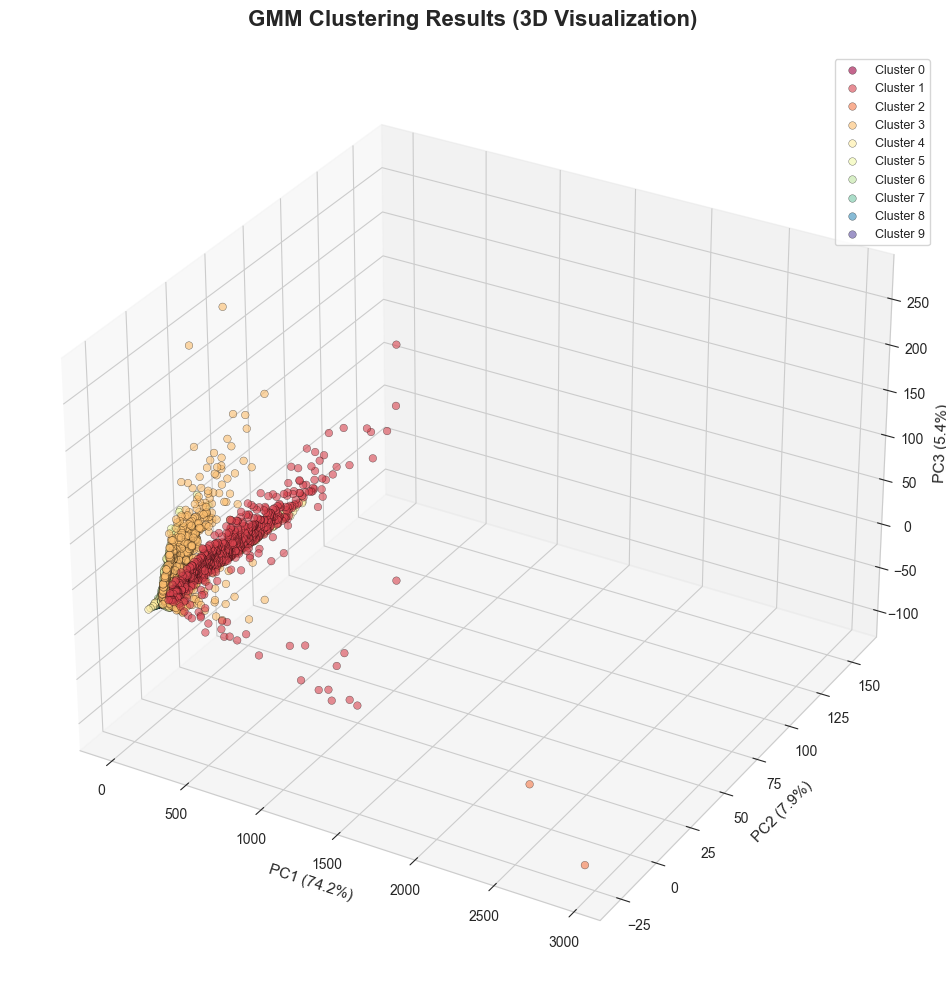

✓ 3D cluster plot saved to reports/gmm_clusters_3d.png


In [ ]:
# 3D scatter plot using first three principal components
logger.info("Creating 3D cluster visualization...")

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for i in range(best_n_clusters):
    cluster_data = X_pca[cluster_labels == i]
    ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
              c=[colors[i]], label=f'Cluster {i}', 
              alpha=0.6, s=30, edgecolors='black', linewidth=0.3)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)', fontsize=11)
ax.set_title('GMM Clustering Results (3D Visualization)', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/gmm_clusters_3d.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 3D cluster plot saved to reports/gmm_clusters_3d.png")

In [ ]:
# Interactive 3D plot using Plotly
logger.info("Creating interactive 3D visualization...")

df_plot = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2],
    'Cluster': cluster_labels.astype(str),
    'Confidence': cluster_probs.max(axis=1)
})

fig = px.scatter_3d(
    df_plot, x='PC1', y='PC2', z='PC3',
    color='Cluster',
    hover_data=['Confidence'],
    title='Interactive GMM Clustering (3D)',
    labels={
        'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'
    },
    opacity=0.7
)

fig.update_layout(
    width=1000,
    height=800,
    font=dict(size=12)
)

fig.write_html('../reports/gmm_clusters_interactive.html')
fig.show()

print("✓ Interactive 3D plot saved to reports/gmm_clusters_interactive.html")

2026-01-30 11:11:57,168 - INFO - Creating interactive 3D visualization...


✓ Interactive 3D plot saved to reports/gmm_clusters_interactive.html


2026-01-30 11:11:59,409 - INFO - Creating cluster probability visualizations...


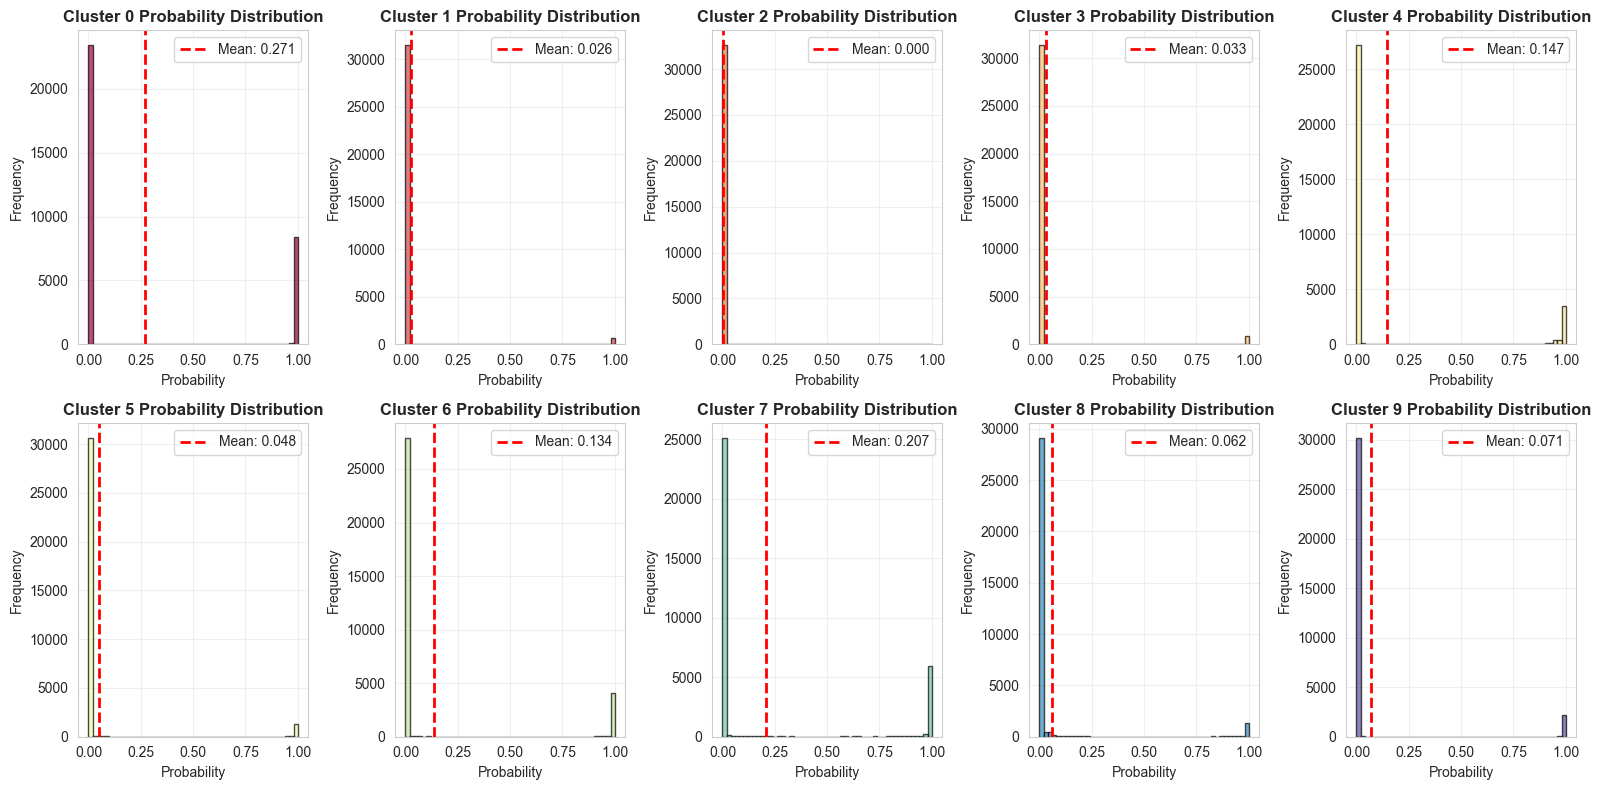

✓ Cluster probability distributions saved to reports/gmm_cluster_probabilities.png


In [ ]:
# Cluster probability distribution
logger.info("Creating cluster probability visualizations...")

fig, axes = plt.subplots(2, (best_n_clusters + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for i in range(best_n_clusters):
    cluster_prob_i = cluster_probs[:, i]
    axes[i].hist(cluster_prob_i, bins=50, edgecolor='black', alpha=0.7, color=colors[i])
    axes[i].set_title(f'Cluster {i} Probability Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Probability', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(alpha=0.3)
    axes[i].axvline(x=cluster_prob_i.mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {cluster_prob_i.mean():.3f}')
    axes[i].legend()

# Hide extra subplots if any
for i in range(best_n_clusters, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('../reports/gmm_cluster_probabilities.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Cluster probability distributions saved to reports/gmm_cluster_probabilities.png")

2026-01-30 11:12:01,856 - INFO - Creating feature importance visualization...


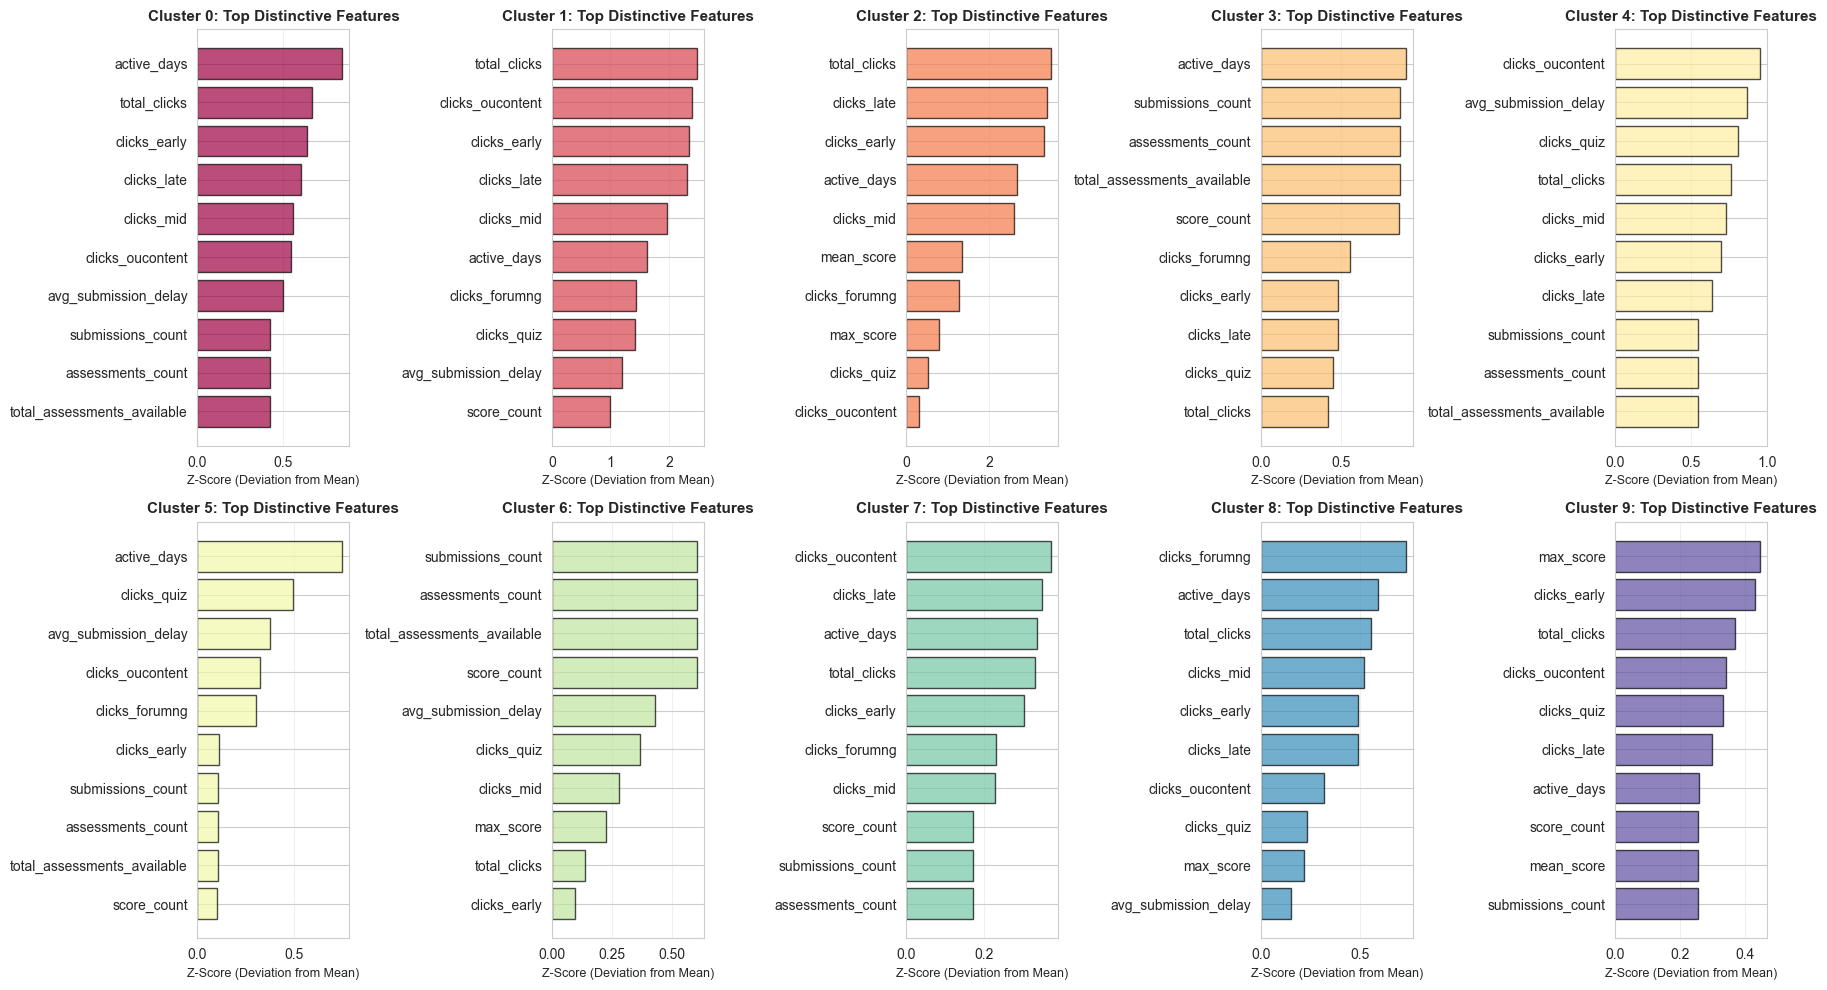

✓ Feature importance plot saved to reports/gmm_feature_importance.png


In [ ]:
# Feature importance for clusters (using mean absolute difference from overall mean)
logger.info("Creating feature importance visualization...")

# Calculate feature importance for each cluster
feature_importance = {}
for cluster in range(best_n_clusters):
    cluster_data = df[df['cluster'] == cluster]
    importance = {}
    
    for feature in profiling_features:
        cluster_mean = cluster_data[feature].mean()
        overall_mean = df[feature].mean()
        overall_std = df[feature].std()
        
        if overall_std > 0:
            z_score = abs((cluster_mean - overall_mean) / overall_std)
            importance[feature] = z_score
    
    feature_importance[cluster] = importance

# Plot top features for each cluster
fig, axes = plt.subplots(2, (best_n_clusters + 1) // 2, figsize=(18, 10))
axes = axes.flatten()

for cluster in range(best_n_clusters):
    # Get top 10 features
    top_features = sorted(feature_importance[cluster].items(), key=lambda x: x[1], reverse=True)[:10]
    features = [f[0] for f in top_features]
    scores = [f[1] for f in top_features]
    
    axes[cluster].barh(features, scores, color=colors[cluster], alpha=0.7, edgecolor='black')
    axes[cluster].set_title(f'Cluster {cluster}: Top Distinctive Features', fontsize=11, fontweight='bold')
    axes[cluster].set_xlabel('Z-Score (Deviation from Mean)', fontsize=9)
    axes[cluster].grid(alpha=0.3, axis='x')
    axes[cluster].invert_yaxis()

# Hide extra subplots if any
for i in range(best_n_clusters, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('../reports/gmm_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance plot saved to reports/gmm_feature_importance.png")

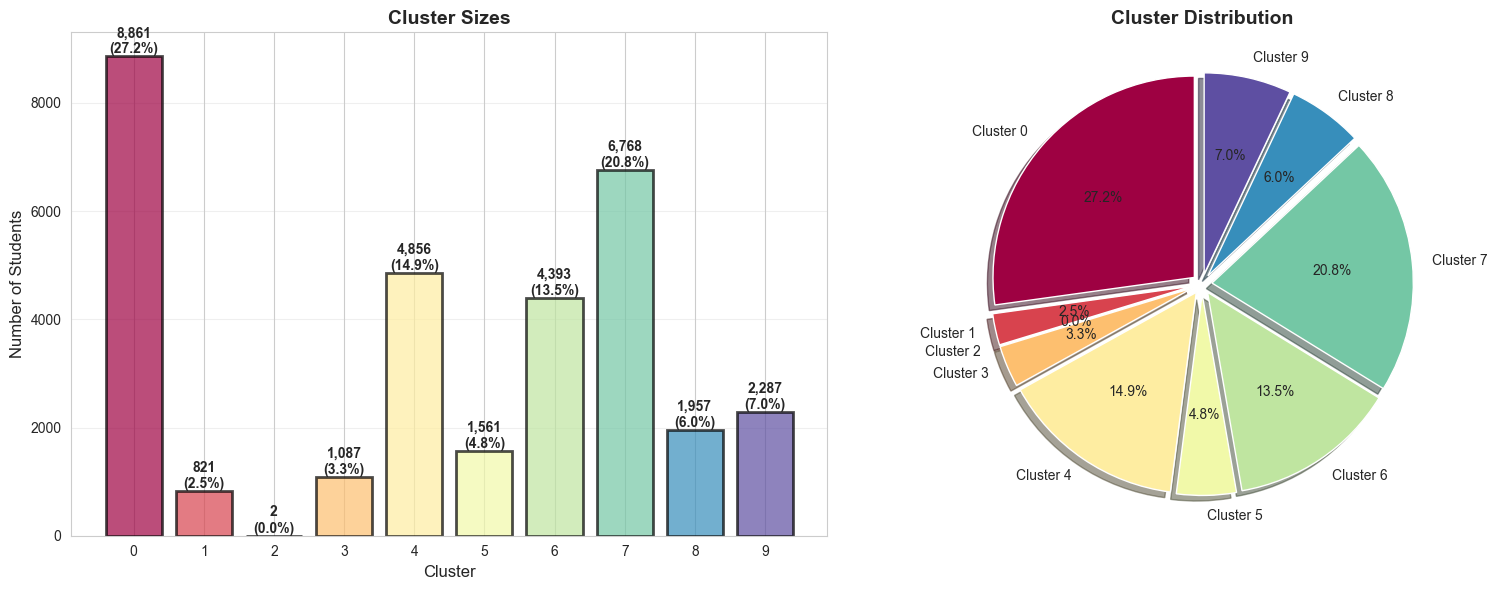

✓ Cluster size plots saved to reports/gmm_cluster_sizes.png


In [ ]:
# Cluster size visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
axes[0].bar(range(best_n_clusters), cluster_counts.values, 
           color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Number of Students', fontsize=12)
axes[0].set_title('Cluster Sizes', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(best_n_clusters))
axes[0].grid(alpha=0.3, axis='y')

# Add value labels on bars
for i, count in enumerate(cluster_counts.values):
    axes[0].text(i, count, f'{count:,}\n({count/len(df)*100:.1f}%)', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(cluster_counts.values, labels=[f'Cluster {i}' for i in range(best_n_clusters)],
           autopct='%1.1f%%', colors=colors, startangle=90, 
           explode=[0.05] * best_n_clusters, shadow=True)
axes[1].set_title('Cluster Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/gmm_cluster_sizes.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Cluster size plots saved to reports/gmm_cluster_sizes.png")

## 8. Results Export <a id='export'></a>

In [ ]:
# Export cluster assignments
logger.info("Exporting cluster assignments...")

# Create output dataframe with identifiers and cluster info
output_df = df[id_columns + ['cluster', 'cluster_confidence']].copy()
output_df.to_csv('../reports/gmm_cluster_assignments.csv', index=False)

print("✓ Cluster assignments saved to reports/gmm_cluster_assignments.csv")
print(f"  Shape: {output_df.shape}")

2026-01-30 11:12:04,097 - INFO - Exporting cluster assignments...


✓ Cluster assignments saved to reports/gmm_cluster_assignments.csv
  Shape: (32593, 5)


In [ ]:
# Export cluster profiles
logger.info("Exporting cluster profiles...")

cluster_profiles_export = cluster_comparison.T
cluster_profiles_export.to_csv('../reports/gmm_cluster_profiles.csv')

print("✓ Cluster profiles saved to reports/gmm_cluster_profiles.csv")
print(f"  Shape: {cluster_profiles_export.shape}")

2026-01-30 11:12:04,158 - INFO - Exporting cluster profiles...


✓ Cluster profiles saved to reports/gmm_cluster_profiles.csv
  Shape: (18, 10)


In [ ]:
# Export model selection results
logger.info("Exporting model selection results...")

results_df.to_csv('../reports/gmm_model_selection_results.csv', index=False)

print("✓ Model selection results saved to reports/gmm_model_selection_results.csv")
print(f"  Shape: {results_df.shape}")

2026-01-30 11:12:04,171 - INFO - Exporting model selection results...


✓ Model selection results saved to reports/gmm_model_selection_results.csv
  Shape: (36, 10)


In [ ]:
# Save the trained GMM model
logger.info("Saving trained GMM model...")

model_artifacts = {
    'gmm_model': final_gmm,
    'pca_model': pca,
    'scaler': scaler,
    'imputer': imputer,
    'feature_names': features_for_clustering,
    'best_params': best_params.to_dict(),
    'cluster_counts': cluster_counts.to_dict(),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('../reports/gmm_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("✓ Trained model saved to reports/gmm_model.pkl")
print("\nModel artifacts included:")
print("  - GMM model")
print("  - PCA transformation")
print("  - Feature scaler")
print("  - Missing value imputer")
print("  - Feature names")
print("  - Best parameters")
print("  - Cluster statistics")

2026-01-30 11:12:04,184 - INFO - Saving trained GMM model...


✓ Trained model saved to reports/gmm_model.pkl

Model artifacts included:
  - GMM model
  - PCA transformation
  - Feature scaler
  - Missing value imputer
  - Feature names
  - Best parameters
  - Cluster statistics


In [ ]:
# Create comprehensive summary report
logger.info("Creating summary report...")

summary_report = f"""# GMM Unsupervised Learning Analysis Report

**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

---

## Executive Summary

This report presents the results of Gaussian Mixture Model (GMM) clustering analysis on student learning analytics data.

### Dataset Overview
- **Total Students:** {len(df):,}
- **Total Features:** {len(features_for_clustering)}
- **Features after PCA:** {X_pca.shape[1]}
- **Variance Explained by PCA:** {pca.explained_variance_ratio_.sum()*100:.2f}%

---

## Model Selection Results

### Best Model Configuration
- **Number of Clusters:** {best_n_clusters}
- **Covariance Type:** {best_cov_type}
- **Converged:** {best_params['converged']}
- **Iterations:** {int(best_params['n_iter'])}

### Model Performance Metrics
| Metric | Score |
|--------|-------|
| BIC | {best_params['bic']:,.2f} |
| AIC | {best_params['aic']:,.2f} |
| Log Likelihood | {best_params['log_likelihood']:,.2f} |
| Silhouette Score | {best_params['silhouette_score']:.4f} |
| Calinski-Harabasz Score | {best_params['calinski_harabasz_score']:,.2f} |
| Davies-Bouldin Score | {best_params['davies_bouldin_score']:.4f} |

---

## Cluster Distribution

| Cluster | Count | Percentage |
|---------|-------|------------|
"""

for cluster in range(best_n_clusters):
    count = cluster_counts[cluster]
    percentage = (count / len(df)) * 100
    summary_report += f"| {cluster} | {count:,} | {percentage:.2f}% |\n"

summary_report += f"""
---

## Cluster Characteristics

"""

for cluster in range(best_n_clusters):
    cluster_data = df[df['cluster'] == cluster]
    summary_report += f"""\n### Cluster {cluster} ({cluster_counts[cluster]:,} students, {(cluster_counts[cluster]/len(df)*100):.1f}%)

**Key Characteristics:**
- **Mean Score:** {cluster_data['mean_score'].mean():.2f}
- **Total Clicks:** {cluster_data['total_clicks'].mean():.2f}
- **Active Days:** {cluster_data['active_days'].mean():.2f}
- **Assessments Count:** {cluster_data['assessments_count'].mean():.2f}
- **Submissions Count:** {cluster_data['submissions_count'].mean():.2f}
- **Missed Submissions:** {cluster_data['missed_submissions_count'].mean():.2f}
- **Avg Submission Delay:** {cluster_data['avg_submission_delay'].mean():.2f}
- **Cluster Confidence:** {cluster_data['cluster_confidence'].mean():.4f}

"""

summary_report += f"""
---

## Files Generated

### Data Files
- `gmm_cluster_assignments.csv` - Cluster assignments for each student
- `gmm_cluster_profiles.csv` - Detailed cluster profiles with statistics
- `gmm_model_selection_results.csv` - Model selection metrics for all tested configurations

### Model Files
- `gmm_model.pkl` - Trained GMM model with all preprocessing artifacts

### Visualizations
- `gmm_feature_distributions.png` - Distribution of key features
- `gmm_correlation_heatmap.png` - Feature correlation heatmap
- `gmm_pca_variance.png` - PCA variance explained plots
- `gmm_model_selection.png` - Model selection criteria plots
- `gmm_silhouette_plot.png` - Silhouette analysis per cluster
- `gmm_clusters_2d.png` - 2D cluster visualization
- `gmm_clusters_3d.png` - 3D cluster visualization
- `gmm_clusters_interactive.html` - Interactive 3D visualization
- `gmm_cluster_probabilities.png` - Cluster probability distributions
- `gmm_feature_importance.png` - Feature importance per cluster
- `gmm_cluster_sizes.png` - Cluster size distribution

---

## Interpretation Guide

### Silhouette Score
- Range: [-1, 1]
- Higher is better
- > 0.5: Strong cluster structure
- 0.25-0.5: Weak but acceptable structure
- < 0.25: No substantial structure

### BIC/AIC
- Lower is better
- Used for model selection
- Balance between fit and complexity

### Calinski-Harabasz Score
- Higher is better
- Ratio of between-cluster to within-cluster variance

### Davies-Bouldin Score
- Lower is better
- Average similarity between clusters

---

## Recommendations

1. **Review cluster profiles** to understand student behavior patterns
2. **Use cluster assignments** for targeted interventions
3. **Monitor cluster confidence** to identify students with ambiguous behavior
4. **Compare with supervised model results** to validate findings
5. **Update model periodically** as new data becomes available

---

**End of Report**
"""

# Save report
with open('../reports/gmm_analysis_report.md', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print("✓ Summary report saved to reports/gmm_analysis_report.md")
print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nAll results have been saved to the '../reports/' directory.")
print(f"Total files generated: 14 (3 CSV + 1 PKL + 1 HTML + 1 MD + 11 PNG)")

2026-01-30 11:12:04,201 - INFO - Creating summary report...


✓ Summary report saved to reports/gmm_analysis_report.md

ANALYSIS COMPLETE!

All results have been saved to the '../reports/' directory.
Total files generated: 14 (3 CSV + 1 PKL + 1 HTML + 1 MD + 11 PNG)


## 9. Conclusions <a id='conclusions'></a>

In [ ]:
# Print final summary
print("="*80)
print("GMM CLUSTERING ANALYSIS - FINAL SUMMARY")
print("="*80)
print(f"\n✓ Successfully clustered {len(df):,} students into {best_n_clusters} distinct groups")
print(f"✓ Model quality metrics:")
print(f"  - Silhouette Score: {best_params['silhouette_score']:.4f}")
print(f"  - BIC: {best_params['bic']:,.2f}")
print(f"  - Average Cluster Confidence: {df['cluster_confidence'].mean():.4f}")
print(f"\n✓ Identified distinct student behavior patterns:")
for cluster in range(best_n_clusters):
    print(f"  - Cluster {cluster}: {cluster_counts[cluster]:,} students ({(cluster_counts[cluster]/len(df)*100):.1f}%)")
print(f"\n✓ Generated comprehensive visualizations and reports")
print(f"✓ Exported cluster assignments and profiles for further analysis")
print(f"✓ Saved trained model for future predictions")
print("\n" + "="*80)
print("Next Steps:")
print("="*80)
print("1. Review cluster profiles to understand student segments")
print("2. Compare GMM clusters with supervised model results")
print("3. Use cluster insights for targeted educational interventions")
print("4. Monitor cluster membership changes over time")
print("5. Refine features or model parameters based on domain knowledge")
print("\n✨ Analysis complete! Check the reports/ directory for all outputs.")

GMM CLUSTERING ANALYSIS - FINAL SUMMARY

✓ Successfully clustered 32,593 students into 10 distinct groups
✓ Model quality metrics:
  - Silhouette Score: 0.0197
  - BIC: 155,671.80
  - Average Cluster Confidence: 0.9799

✓ Identified distinct student behavior patterns:
  - Cluster 0: 8,861 students (27.2%)
  - Cluster 1: 821 students (2.5%)
  - Cluster 2: 2 students (0.0%)
  - Cluster 3: 1,087 students (3.3%)
  - Cluster 4: 4,856 students (14.9%)
  - Cluster 5: 1,561 students (4.8%)
  - Cluster 6: 4,393 students (13.5%)
  - Cluster 7: 6,768 students (20.8%)
  - Cluster 8: 1,957 students (6.0%)
  - Cluster 9: 2,287 students (7.0%)

✓ Generated comprehensive visualizations and reports
✓ Exported cluster assignments and profiles for further analysis
✓ Saved trained model for future predictions

Next Steps:
1. Review cluster profiles to understand student segments
2. Compare GMM clusters with supervised model results
3. Use cluster insights for targeted educational interventions
4. Monitor 